# Exploration 

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

from __future__ import annotations

import os
import json
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import wfdb
from tqdm.auto import tqdm
from joblib import Parallel, delayed

from scipy.signal import welch, butter, filtfilt
from scipy.stats import skew, kurtosis

import neurokit2 as nk

import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

# Optional seaborn (never required)
try:
    import seaborn as sns  # noqa: F401
    _HAS_SEABORN = True
except Exception:
    _HAS_SEABORN = False

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier

warnings.filterwarnings("ignore")

# avoid oversubscription
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

EPS = 1e-12


/opt/anaconda3/envs/jax_gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/jax_gpu/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
# =============================================================================
# Configuration
# =============================================================================

@dataclass(frozen=True)
class Config:
    data_root: Path
    cache_dir: Path
    max_records: Optional[int] = None
    n_jobs: int = -1
    leads: Tuple[int, ...] = (0, 1, 2)

    # Bayesian models
    n_clusters: int = 4
    draws: int = 2000
    tune: int = 2000
    chains: int = 4
    target_accept: float = 0.90
    random_seed: int = 42

    # Preprocessing defaults
    bp_low: float = 0.5
    bp_high: float = 40.0
    bp_order: int = 3

    @property
    def db_csv(self) -> Path:
        return self.data_root / "ptbxl_database.csv"

    @property
    def features_csv(self) -> Path:
        return self.cache_dir / "features_quality.csv"

    @property
    def errors_jsonl(self) -> Path:
        return self.cache_dir / "feature_errors.jsonl"

    @property
    def trace_binlogit_nc(self) -> Path:
        return self.cache_dir / "trace_binlogit.nc"

    @property
    def trace_binmix_nc(self) -> Path:
        return self.cache_dir / f"trace_binmix_k{self.n_clusters}.nc"


In [3]:
# =============================================================================
# Configuration + Run Control
# =============================================================================

@dataclass(frozen=True)
class Config:
    data_root: Path
    cache_dir: Path

    # feature extraction
    max_records: Optional[int] = None
    n_jobs: int = -1
    leads: Tuple[int, ...] = (0, 1, 2)

    # preprocessing
    bp_low: float = 0.5
    bp_high: float = 40.0
    bp_order: int = 3

    # Bayesian logistic
    draws: int = 2000
    tune: int = 2000
    chains: int = 4
    target_accept: float = 0.90
    random_seed: int = 42

    # mixture (optional)
    n_clusters: int = 4

    @property
    def db_csv(self) -> Path:
        return self.data_root / "ptbxl_database.csv"

    @property
    def features_csv(self) -> Path:
        return self.cache_dir / "features_quality.csv"

    @property
    def errors_jsonl(self) -> Path:
        return self.cache_dir / "feature_errors.jsonl"

    @property
    def trace_binlogit_nc(self) -> Path:
        return self.cache_dir / "trace_binlogit.nc"

    @property
    def anomaly_dir(self) -> Path:
        return self.cache_dir / "anomaly_results"


@dataclass(frozen=True)
class RunOptions:
    """
    mode:
      - "cache": use cached artifacts if present (features, trace). Build only if missing.
      - "fresh": ignore caches, rebuild everything from scratch.

    You can also control each artifact explicitly.
    """
    mode: str = "cache"  # "cache" or "fresh"

    use_cached_features: Optional[bool] = None
    use_cached_trace: Optional[bool] = None

    def resolve(self):
        if self.mode not in ("cache", "fresh"):
            raise ValueError("RunOptions.mode must be 'cache' or 'fresh'")

        if self.use_cached_features is None:
            use_feat = (self.mode == "cache")
        else:
            use_feat = bool(self.use_cached_features)

        if self.use_cached_trace is None:
            use_trace = (self.mode == "cache")
        else:
            use_trace = bool(self.use_cached_trace)

        return use_feat, use_trace


In [4]:
# =============================================================================
# Utilities
# =============================================================================

def _trapz_robust(y: np.ndarray, x: np.ndarray) -> float:
    try:
        return float(np.trapezoid(y, x))
    except AttributeError:
        return float(np.trapz(y, x))


def _welch_psd(x: np.ndarray, fs: float, nperseg: int = 1024):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 16 or fs <= 0:
        return None, None
    nperseg = min(int(nperseg), x.size)
    if nperseg < 16:
        return None, None
    f, pxx = welch(x, fs=fs, nperseg=nperseg, scaling="density")
    return f, pxx


def _bandpower(f, pxx, low: float, high: float) -> float:
    if f is None or pxx is None:
        return np.nan
    m = (f >= low) & (f < high)
    if not np.any(m):
        return 0.0
    return _trapz_robust(pxx[m], f[m])


def _safe_float(x: Any, default: float = 0.0) -> float:
    try:
        if x is None or (isinstance(x, str) and x.strip() == ""):
            return default
        v = float(x)
        return default if (np.isnan(v) or np.isinf(v)) else v
    except Exception:
        return default


def _resolve_record_base(data_root: Path, rel_path: str) -> Optional[Path]:
    rel = str(rel_path).replace("\\", "/")
    rel = os.path.splitext(rel)[0]

    base = data_root / rel
    if base.with_suffix(".hea").exists():
        return base

    base2 = data_root / "records500" / rel
    if base2.with_suffix(".hea").exists():
        return base2

    return None


def _bandpass_filter(x: np.ndarray, fs: float, low: float, high: float, order: int = 3) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if x.size < 64 or fs <= 0:
        return x
    nyq = 0.5 * fs
    lo = max(low / nyq, 1e-6)
    hi = min(high / nyq, 0.999999)
    if not (0 < lo < hi < 1):
        return x
    try:
        b, a = butter(order, [lo, hi], btype="bandpass")
        padlen = min(3 * (max(len(a), len(b)) - 1), x.size - 1)
        if padlen < 1:
            return x
        return filtfilt(b, a, x, padlen=padlen)
    except Exception:
        return x


def load_ptbxl_database(cfg: Config) -> pd.DataFrame:
    if not cfg.db_csv.exists():
        raise FileNotFoundError(f"Missing ptbxl_database.csv at: {cfg.db_csv}")
    return pd.read_csv(cfg.db_csv)


def create_degradation_labels(db: pd.DataFrame) -> np.ndarray:
    noise_cols = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems"]
    missing = [c for c in noise_cols if c not in db.columns]
    if missing:
        raise ValueError(f"Missing expected noise columns: {missing}")

    def to_flag(x: Any) -> int:
        if pd.isna(x):
            return 0
        s = str(x).strip()
        if s == "" or s.lower() == "nan":
            return 0
        try:
            return int(float(s) != 0.0)
        except Exception:
            return 1

    flags = db[noise_cols].applymap(to_flag)
    return (flags.sum(axis=1) > 0).astype(int).to_numpy()


In [5]:
# =============================================================================
# Feature Extraction
# =============================================================================

def _template_corr_feature(
    x: np.ndarray,
    rpeaks: np.ndarray,
    fs: float,
    w_pre: float = 0.30,
    w_post: float = 0.50,
    max_beats: int = 40
) -> float:
    """
    Beat-template correlation SQI (often referred to as cSQI / template-correlation SQI in the literature family).
    """
    if rpeaks.size < 3:
        return 0.0

    pre = int(w_pre * fs)
    post = int(w_post * fs)
    if pre < 5 or post < 5:
        return 0.0

    beats = []
    idxs = np.linspace(0, rpeaks.size - 1, min(max_beats, rpeaks.size)).astype(int)
    for i in idxs:
        rp = int(rpeaks[i])
        a, b = rp - pre, rp + post
        if a < 0 or b > x.size:
            continue
        seg = x[a:b].astype(float)
        if seg.size < (pre + post - 2) or np.any(~np.isfinite(seg)):
            continue
        seg = (seg - np.mean(seg)) / (np.std(seg) + EPS)
        beats.append(seg)

    if len(beats) < 3:
        return 0.0

    B = np.vstack(beats)
    tmpl = B.mean(axis=0)
    tmpl = (tmpl - tmpl.mean()) / (np.std(tmpl) + EPS)
    corrs = (B @ tmpl) / (tmpl.size - 1 + EPS)
    return float(np.mean(np.clip(corrs, -1.0, 1.0)))


def compute_quality_features_1lead(x: np.ndarray, fs: float, cfg: Config) -> Dict[str, float]:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    out = {k: 0.0 for k in [
        "x_mean", "x_std", "x_skew", "x_kurtosis",

        # spectral powers
        "p_0_1", "p_0_40", "p_5_15", "p_5_40", "p_40_100", "p_45_55", "p_tot",

        # common literature-aligned SQIs/ratios
        "pSQI", "basSQI", "hf_ratio", "powerline_ratio",
        "frac_base", "frac_qrs", "frac_hf",

        # RR/beat features
        "n_peaks", "rr_mean", "rr_sd", "rr_cv",
        "rr_oob_frac", "rr_med_dev_frac", "rr_jump_frac",

        # beat-template consistency (aka cSQI family)
        "tmpl_corr", "cSQI"
    ]}

    if x.size < 64 or fs <= 0:
        return out

    # preprocessing: bandpass then neurokit clean for peaks
    x_f = _bandpass_filter(x, fs, cfg.bp_low, cfg.bp_high, cfg.bp_order)

    out["x_mean"] = float(np.mean(x_f))
    out["x_std"] = float(np.std(x_f))
    out["x_skew"] = float(skew(x_f)) if x_f.size >= 8 else 0.0
    out["x_kurtosis"] = float(kurtosis(x_f)) if x_f.size >= 8 else 0.0

    f, pxx = _welch_psd(x_f, fs)
    out["p_0_1"] = _safe_float(_bandpower(f, pxx, 0.0, 1.0))
    out["p_0_40"] = _safe_float(_bandpower(f, pxx, 0.0, 40.0))
    out["p_5_15"] = _safe_float(_bandpower(f, pxx, 5.0, 15.0))
    out["p_5_40"] = _safe_float(_bandpower(f, pxx, 5.0, 40.0))
    out["p_40_100"] = _safe_float(_bandpower(f, pxx, 40.0, min(100.0, fs / 2.0)))
    out["p_45_55"] = _safe_float(_bandpower(f, pxx, 45.0, min(55.0, fs / 2.0)))
    out["p_tot"] = _safe_float(_bandpower(f, pxx, 0.0, fs / 2.0))

    # Literature-aligned definitions (keep these consistent across pipelines!)
    # basSQI ~ 1 - P(0-1)/P(0-40)
    # pSQI ~ P(5-15)/P(5-40)
    # hf_ratio ~ P(40-100)/P(5-40)
    # powerline_ratio ~ P(45-55)/P(total)  (proxy for mains)
    out["pSQI"] = float(out["p_5_15"] / (out["p_5_40"] + EPS))
    out["basSQI"] = float(1.0 - (out["p_0_1"] / (out["p_0_40"] + EPS)))
    out["hf_ratio"] = float(out["p_40_100"] / (out["p_5_40"] + EPS))
    out["powerline_ratio"] = float(out["p_45_55"] / (out["p_tot"] + EPS))

    out["frac_base"] = float(out["p_0_1"] / (out["p_tot"] + EPS))
    out["frac_qrs"] = float(out["p_5_40"] / (out["p_tot"] + EPS))
    out["frac_hf"] = float(out["p_40_100"] / (out["p_tot"] + EPS))

    try:
        x_clean = nk.ecg_clean(x_f, sampling_rate=fs, method="neurokit")
        _, rdict = nk.ecg_peaks(x_clean, sampling_rate=fs)
        rpeaks = np.asarray(rdict.get("ECG_R_Peaks", []), dtype=int)

        out["n_peaks"] = float(rpeaks.size)

        if rpeaks.size >= 2:
            rr = np.diff(rpeaks) / float(fs)
            rr = rr[np.isfinite(rr)]
            if rr.size:
                rr_mean = float(np.mean(rr))
                rr_sd = float(np.std(rr))
                out["rr_mean"] = rr_mean
                out["rr_sd"] = rr_sd
                out["rr_cv"] = float(rr_sd / (rr_mean + EPS))

                oob = (rr < 0.333) | (rr > 2.0)
                out["rr_oob_frac"] = float(np.mean(oob))

                rr2 = rr[~oob]
                if rr2.size:
                    med = float(np.median(rr2))
                    dev = np.abs(rr2 - med) / (med + EPS)
                    out["rr_med_dev_frac"] = float(np.mean(dev > 0.33))
                else:
                    out["rr_med_dev_frac"] = 1.0

                jumps = np.abs(np.diff(rr))
                out["rr_jump_frac"] = float(np.mean(jumps > 0.2)) if jumps.size else 0.0

        # Template correlation (cSQI-family)
        out["tmpl_corr"] = _template_corr_feature(x_clean, rpeaks, fs)
        out["cSQI"] = out["tmpl_corr"]  # alias with literature-friendly name
    except Exception:
        pass

    # clamp unstable
    out["basSQI"] = float(np.clip(out["basSQI"], -1.0, 1.0))
    out["pSQI"] = float(np.clip(out["pSQI"], 0.0, 2.0))
    out["hf_ratio"] = float(np.clip(out["hf_ratio"], 0.0, 50.0))
    out["powerline_ratio"] = float(np.clip(out["powerline_ratio"], 0.0, 1.0))
    out["tmpl_corr"] = float(np.clip(out["tmpl_corr"], -1.0, 1.0))
    out["cSQI"] = float(np.clip(out["cSQI"], -1.0, 1.0))

    return out


def _aggregate_lead_features(per_lead: List[Dict[str, float]]) -> Dict[str, float]:
    if not per_lead:
        return {}
    keys = sorted(per_lead[0].keys())
    mat = np.array([[d.get(k, 0.0) for k in keys] for d in per_lead], dtype=float)
    agg: Dict[str, float] = {}
    for j, k in enumerate(keys):
        col = mat[:, j]
        agg[f"{k}_mean"] = float(np.mean(col))
        agg[f"{k}_min"] = float(np.min(col))
        agg[f"{k}_max"] = float(np.max(col))
    return agg


def process_single_record(
    idx: int, rel_path: str, data_root: Path, y_val: int, ecg_id: Any,
    leads: Tuple[int, ...], cfg: Config
):
    base = _resolve_record_base(data_root, rel_path)
    if base is None:
        return None, {"idx": idx, "ecg_id": ecg_id, "rel_path": rel_path, "error": "missing_record"}

    try:
        sig, fields = wfdb.rdsamp(str(base))
        fs = float(fields.get("fs", 500.0))
        if sig.ndim != 2:
            return None, {"idx": idx, "ecg_id": ecg_id, "rel_path": rel_path, "error": "bad_signal_shape"}

        n_leads = sig.shape[1]
        use_leads = [l for l in leads if 0 <= l < n_leads] or [0]

        per_lead = [compute_quality_features_1lead(sig[:, l], fs, cfg) for l in use_leads]
        feats = _aggregate_lead_features(per_lead)

        row: Dict[str, Any] = {"ecg_id": ecg_id, "y": int(y_val), "fs": fs, "n_leads_used": int(len(use_leads))}
        row.update(feats)
        return row, None

    except Exception as e:
        return None, {"idx": idx, "ecg_id": ecg_id, "rel_path": rel_path, "error": f"{type(e).__name__}: {e}"}


def build_features(db: pd.DataFrame, y: np.ndarray, cfg: Config) -> pd.DataFrame:
    cfg.cache_dir.mkdir(parents=True, exist_ok=True)

    n_use = len(db) if cfg.max_records is None else min(cfg.max_records, len(db))
    db_sub = db.iloc[:n_use].reset_index(drop=True)
    y_sub = y[:n_use]

    if cfg.errors_jsonl.exists():
        cfg.errors_jsonl.unlink()

    def _job(i: int):
        return process_single_record(
            idx=i,
            rel_path=str(db_sub.loc[i, "filename_hr"]),
            data_root=cfg.data_root,
            y_val=int(y_sub[i]),
            ecg_id=db_sub.loc[i, "ecg_id"] if "ecg_id" in db_sub.columns else i,
            leads=cfg.leads,
            cfg=cfg,
        )

    results = Parallel(n_jobs=cfg.n_jobs, backend="loky")(
        delayed(_job)(i) for i in tqdm(range(n_use), desc="Extracting features")
    )

    rows, errs = [], []
    for row, err in results:
        if row is not None:
            rows.append(row)
        if err is not None:
            errs.append(err)

    if errs:
        with open(cfg.errors_jsonl, "w", encoding="utf-8") as f:
            for e in errs:
                f.write(json.dumps(e) + "\n")

    if not rows:
        raise RuntimeError("No features extracted. Check paths and filename_hr resolution.")

    feat_df = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    print(f"\nFeature extraction: {len(rows)}/{n_use} successful")
    if errs:
        print(f"Error log: {cfg.errors_jsonl}")

    return feat_df


def load_or_build_features(
    db: pd.DataFrame,
    y: np.ndarray,
    cfg: Config,
    use_cache: bool = True,
    overwrite_cache: bool = True
) -> pd.DataFrame:
    """
    Flexible feature caching:
      - use_cache=True  -> load cfg.features_csv if valid
      - use_cache=False -> rebuild features

    Saving behavior:
      - overwrite_cache=True  -> save to cfg.features_csv (overwrites)
      - overwrite_cache=False -> save to timestamped file, keep existing cache intact
    """
    cfg.cache_dir.mkdir(parents=True, exist_ok=True)

    expected_n = len(db) if cfg.max_records is None else min(cfg.max_records, len(db))

    if use_cache and cfg.features_csv.exists():
        feat_df = pd.read_csv(cfg.features_csv)
        if len(feat_df) == expected_n and "y" in feat_df.columns:
            if int(feat_df["y"].sum()) == int(y[:len(feat_df)].sum()):
                print(f"Loaded cached features: {cfg.features_csv} (n={len(feat_df)})")
                return feat_df
        print("Cached features invalid (shape/labels mismatch), rebuilding.")

    feat_df = build_features(db, y, cfg)

    if overwrite_cache:
        feat_df.to_csv(cfg.features_csv, index=False)
        print(f"Saved: {cfg.features_csv}")
    else:
        ts = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        out_path = cfg.cache_dir / f"features_quality_{ts}.csv"
        feat_df.to_csv(out_path, index=False)
        print(f"Saved (timestamped): {out_path}")

    return feat_df


In [137]:
# =============================================================================
# (A) Bayesian Binary Logistic Regression (separate module-style section)
# =============================================================================

def fit_binary_logistic(feat_df: pd.DataFrame, cfg: Config):
    feature_cols = [c for c in feat_df.columns if c not in ("ecg_id", "y")]
    X = feat_df[feature_cols].to_numpy(dtype=np.float32)
    y = feat_df["y"].to_numpy(dtype=np.int32)

    if not np.isfinite(X).all():
        bad = np.where(~np.isfinite(X))
        raise ValueError(f"Non-finite values in X at {list(zip(bad[0][:5], bad[1][:5]))}")

    X_mean = X.mean(axis=0, dtype=np.float32)
    X_std = X.std(axis=0, dtype=np.float32) + np.float32(1e-6)
    Xz = ((X - X_mean) / X_std).astype(np.float32)

    N, D = Xz.shape
    print(f"\nBinary logistic: N={N}, D={D}, degraded={y.mean():.3f}")

    # ---- IMPORTANT ----
    # Multiprocessing sometimes dies with EOFError (worker crash / OOM / MKL/OpenBLAS issues).
    # We try normal sampling first; if it crashes, we fall back to a safer configuration.
    cores = min(4, cfg.chains)

    with pm.Model() as model:
        X_data = pm.Data("X", Xz)
        y_data = pm.Data("y", y)

        tau = pm.HalfNormal("tau", 0.5)
        beta = pm.Normal("beta", 0.0, tau, shape=D)
        alpha = pm.Normal("alpha", 0.0, 1.0)

        eta = pt.clip(alpha + pt.dot(X_data, beta), -20, 20)
        pm.Bernoulli("obs", logit_p=eta, observed=y_data)

        try:
            # Attempt 1: default PyMC NUTS (may use multiprocessing)
            trace = pm.sample(
                draws=cfg.draws,
                tune=cfg.tune,
                chains=cfg.chains,
                cores=cores,
                target_accept=cfg.target_accept,
                random_seed=cfg.random_seed,
                init="adapt_diag",
                progressbar=True,
                idata_kwargs={"log_likelihood": True},
            )

        except EOFError as e:
            print(
                "\n[WARN] Multiprocess sampling crashed with EOFError.\n"
                "Falling back to a safer sampler configuration (NumPyro vectorized chains)."
            )

            # Attempt 2: NumPyro NUTS (single process, vectorized chains) – usually avoids EOFError
            try:
                trace = pm.sample(
                    draws=cfg.draws,
                    tune=cfg.tune,
                    chains=cfg.chains,
                    cores=-1,  # keep in one OS process
                    target_accept=cfg.target_accept,
                    random_seed=cfg.random_seed,
                    init="adapt_diag",
                    progressbar=True,
                    nuts_sampler="numpyro",
                    nuts_sampler_kwargs={"chain_method": "vectorized"},
                    idata_kwargs={"log_likelihood": True},
                )
            except Exception:
                # Attempt 3: Last resort – single-core PyMC NUTS
                print(
                    "\n[WARN] NumPyro fallback failed.\n"
                    "Falling back to single-core PyMC sampling (cores=1)."
                )
                trace = pm.sample(
                    draws=cfg.draws,
                    tune=cfg.tune,
                    chains=cfg.chains,
                    cores=4,
                    target_accept=cfg.target_accept,
                    random_seed=cfg.random_seed,
                    init="adapt_diag",
                    progressbar=True,
                    idata_kwargs={"log_likelihood": True},
                )

    return trace, (X_mean, X_std), feature_cols



def run_binary_logistic(feat_df: pd.DataFrame, cfg: Config, use_cache: bool = True):
    if use_cache and cfg.trace_binlogit_nc.exists():
        print(f"Loading cached trace: {cfg.trace_binlogit_nc}")
        trace = az.from_netcdf(cfg.trace_binlogit_nc)

        feature_cols = [c for c in feat_df.columns if c not in ("ecg_id", "y")]
        X = feat_df[feature_cols].to_numpy(dtype=np.float32)
        X_mean = X.mean(axis=0, dtype=np.float32)
        X_std = X.std(axis=0, dtype=np.float32) + np.float32(1e-6)
        return trace, (X_mean, X_std), feature_cols

    # Otherwise refit
    trace, scaler, feature_cols = fit_binary_logistic(feat_df, cfg)

    # Write safely (avoid corrupting cache on crash)
    tmp_path = cfg.trace_binlogit_nc.with_suffix(".nc.tmp")
    trace.to_netcdf(tmp_path)
    os.replace(tmp_path, cfg.trace_binlogit_nc)

    print(f"Saved: {cfg.trace_binlogit_nc}")
    return trace, scaler, feature_cols



def compute_posterior_predictions(trace, X: np.ndarray, scaler):
    X_mean, X_std = scaler
    X = np.asarray(X, dtype=np.float32)
    Xz = (X - X_mean) / X_std

    beta = trace.posterior["beta"]
    alpha = trace.posterior["alpha"]

    beta_s = beta.stack(sample=("chain", "draw")).transpose("sample", "beta_dim_0").values
    alpha_s = alpha.stack(sample=("chain", "draw")).values

    eta = alpha_s[:, None] + beta_s @ Xz.T
    p_post = 1 / (1 + np.exp(-eta))

    return {
        "p_mean": p_post.mean(axis=0),
        "p_lo": np.quantile(p_post, 0.03, axis=0),
        "p_hi": np.quantile(p_post, 0.97, axis=0)
    }


def run_binary_regression_analysis(DATA_ROOT: Path, opts: RunOptions):
    """
    Complete binary regression run.
    - Can rebuild features and/or trace depending on opts.
    - Saves predictions + feature importance csvs.
    """
    cfg = Config(data_root=DATA_ROOT, cache_dir=DATA_ROOT)
    use_feat_cache, use_trace_cache = opts.resolve()

    print("Loading PTB-XL database...")
    db = load_ptbxl_database(cfg)
    y = create_degradation_labels(db)

    print(f"Total records: {len(db)}")
    print(f"Degraded signals: {y.sum()} ({100*y.mean():.1f}%)")

    print("\nPreparing features...")
    feat_df = load_or_build_features(db, y, cfg, use_cache=use_feat_cache)

    print("\nRunning Bayesian logistic regression...")
    trace, scaler, cols = run_binary_logistic(feat_df, cfg, use_cache=use_trace_cache)

    print("\nComputing posterior predictions...")
    X = feat_df[cols].to_numpy(dtype=np.float32)
    preds = compute_posterior_predictions(trace, X, scaler)

    y_true = feat_df["y"].values
    p_hat = preds["p_mean"]
    auc = roc_auc_score(y_true, p_hat)
    print(f"\nROC AUC: {auc:.4f}")

    # Feature importance
    beta_summary = az.summary(trace, var_names=["beta"])
    beta_summary["abs_mean"] = beta_summary["mean"].abs()
    beta_summary["feature"] = cols
    beta_summary = beta_summary.set_index("feature").sort_values("abs_mean", ascending=False)

    # Save predictions + importance
    results_df = feat_df[["ecg_id", "y"]].copy()
    results_df["p_degraded_mean"] = preds["p_mean"]
    results_df["p_degraded_lo"] = preds["p_lo"]
    results_df["p_degraded_hi"] = preds["p_hi"]
    results_df["predicted_class"] = (preds["p_mean"] >= 0.5).astype(int)

    results_path = DATA_ROOT / "predictions_logistic.csv"
    results_df.to_csv(results_path, index=False)
    print(f"Saved: {results_path}")

    importance_path = DATA_ROOT / "feature_importance_logistic.csv"
    beta_summary.to_csv(importance_path)
    print(f"Saved: {importance_path}")

    # Quick plots (optional, safe)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(p_hat[y_true == 0], bins=50, alpha=0.6, label="Clean", density=True)
    ax.hist(p_hat[y_true == 1], bins=50, alpha=0.6, label="Degraded", density=True)
    ax.set_xlabel("Posterior P(degraded)")
    ax.set_ylabel("Density")
    ax.set_title("Posterior Probability Distribution")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / "posterior_prob_hist.png", dpi=300, bbox_inches="tight")
    plt.show()

    return feat_df, trace, scaler, cols, preds, beta_summary


In [140]:
# =============================================================================
# (A) Bayesian Binary Logistic Regression (separate module-style section)
# =============================================================================

def fit_binary_logistic(feat_df: pd.DataFrame, cfg: Config):
    feature_cols = [c for c in feat_df.columns if c not in ("ecg_id", "y")]
    X = feat_df[feature_cols].to_numpy(dtype=np.float32)
    y = feat_df["y"].to_numpy(dtype=np.int32)

    if not np.isfinite(X).all():
        bad = np.where(~np.isfinite(X))
        raise ValueError(f"Non-finite values in X at {list(zip(bad[0][:5], bad[1][:5]))}")

    X_mean = X.mean(axis=0, dtype=np.float32)
    X_std = X.std(axis=0, dtype=np.float32) + np.float32(1e-6)
    Xz = ((X - X_mean) / X_std).astype(np.float32)

    N, D = Xz.shape
    print(f"\nBinary logistic: N={N}, D={D}, degraded={y.mean():.3f}")

    # ---- IMPORTANT ----
    # Multiprocessing sometimes dies with EOFError (worker crash / OOM / MKL/OpenBLAS issues).
    # We try normal sampling first; if it crashes, we fall back to a safer configuration.
    cores = min(4, cfg.chains)

    with pm.Model() as model:
        X_data = pm.Data("X", Xz)
        y_data = pm.Data("y", y)

        tau = pm.HalfNormal("tau", 0.5)
        beta = pm.Normal("beta", 0.0, tau, shape=D)
        alpha = pm.Normal("alpha", 0.0, 1.0)

        eta = pt.clip(alpha + pt.dot(X_data, beta), -20, 20)
        pm.Bernoulli("obs", logit_p=eta, observed=y_data)

        try:
            # Attempt 1: default PyMC NUTS (may use multiprocessing)
            trace = pm.sample(
                draws=cfg.draws,
                tune=cfg.tune,
                chains=cfg.chains,
                cores=cores,
                target_accept=cfg.target_accept,
                random_seed=cfg.random_seed,
                init="adapt_diag",
                progressbar=True,
                idata_kwargs={"log_likelihood": True},
            )

        except EOFError as e:
            print(
                "\n[WARN] Multiprocess sampling crashed with EOFError.\n"
                "Falling back to a safer sampler configuration (NumPyro vectorized chains)."
            )

            # Attempt 2: NumPyro NUTS (single process, vectorized chains) – usually avoids EOFError
            try:
                trace = pm.sample(
                    draws=cfg.draws,
                    tune=cfg.tune,
                    chains=cfg.chains,
                    cores=-1,  # keep in one OS process
                    target_accept=cfg.target_accept,
                    random_seed=cfg.random_seed,
                    init="adapt_diag",
                    progressbar=True,
                    nuts_sampler="numpyro",
                    nuts_sampler_kwargs={"chain_method": "vectorized"},
                    idata_kwargs={"log_likelihood": True},
                )
            except Exception:
                # Attempt 3: Last resort – single-core PyMC NUTS
                print(
                    "\n[WARN] NumPyro fallback failed.\n"
                    "Falling back to single-core PyMC sampling (cores=1)."
                )
                trace = pm.sample(
                    draws=cfg.draws,
                    tune=cfg.tune,
                    chains=cfg.chains,
                    cores=4,
                    target_accept=cfg.target_accept,
                    random_seed=cfg.random_seed,
                    init="adapt_diag",
                    progressbar=True,
                    idata_kwargs={"log_likelihood": True},
                )

    return trace, (X_mean, X_std), feature_cols



def run_binary_logistic(feat_df: pd.DataFrame, cfg: Config, use_cache: bool = True):
    if use_cache and cfg.trace_binlogit_nc.exists():
        print(f"Loading cached trace: {cfg.trace_binlogit_nc}")
        trace = az.from_netcdf(cfg.trace_binlogit_nc)

        feature_cols = [c for c in feat_df.columns if c not in ("ecg_id", "y")]
        X = feat_df[feature_cols].to_numpy(dtype=np.float32)
        X_mean = X.mean(axis=0, dtype=np.float32)
        X_std = X.std(axis=0, dtype=np.float32) + np.float32(1e-6)
        return trace, (X_mean, X_std), feature_cols

    # Otherwise refit
    trace, scaler, feature_cols = fit_binary_logistic(feat_df, cfg)

    # Write safely (avoid corrupting cache on crash)
    tmp_path = cfg.trace_binlogit_nc.with_suffix(".nc.tmp")
    trace.to_netcdf(tmp_path)
    os.replace(tmp_path, cfg.trace_binlogit_nc)

    print(f"Saved: {cfg.trace_binlogit_nc}")
    return trace, scaler, feature_cols



def compute_posterior_predictions(trace, X: np.ndarray, scaler):
    X_mean, X_std = scaler
    X = np.asarray(X, dtype=np.float32)
    Xz = (X - X_mean) / X_std

    beta = trace.posterior["beta"]
    alpha = trace.posterior["alpha"]

    beta_s = beta.stack(sample=("chain", "draw")).transpose("sample", "beta_dim_0").values
    alpha_s = alpha.stack(sample=("chain", "draw")).values

    eta = alpha_s[:, None] + beta_s @ Xz.T
    p_post = 1 / (1 + np.exp(-eta))

    return {
        "p_mean": p_post.mean(axis=0),
        "p_lo": np.quantile(p_post, 0.03, axis=0),
        "p_hi": np.quantile(p_post, 0.97, axis=0)
    }


def run_binary_regression_analysis(DATA_ROOT: Path, opts: RunOptions):
    """
    Complete binary regression run.
    - Can rebuild features and/or trace depending on opts.
    - Saves predictions + feature importance csvs.
    """
    cfg = Config(data_root=DATA_ROOT, cache_dir=DATA_ROOT)
    use_feat_cache, use_trace_cache = opts.resolve()

    print("Loading PTB-XL database...")
    db = load_ptbxl_database(cfg)
    y = create_degradation_labels(db)

    print(f"Total records: {len(db)}")
    print(f"Degraded signals: {y.sum()} ({100*y.mean():.1f}%)")

    print("\nPreparing features...")
    feat_df = load_or_build_features(db, y, cfg, use_cache=use_feat_cache)

    print("\nRunning Bayesian logistic regression...")
    trace, scaler, cols = run_binary_logistic(feat_df, cfg, use_cache=use_trace_cache)

    print("\nComputing posterior predictions...")
    X = feat_df[cols].to_numpy(dtype=np.float32)
    preds = compute_posterior_predictions(trace, X, scaler)

    y_true = feat_df["y"].values
    p_hat = preds["p_mean"]
    auc = roc_auc_score(y_true, p_hat)
    print(f"\nROC AUC: {auc:.4f}")

    # Feature importance
    beta_summary = az.summary(trace, var_names=["beta"])
    beta_summary["abs_mean"] = beta_summary["mean"].abs()
    beta_summary["feature"] = cols
    beta_summary = beta_summary.set_index("feature").sort_values("abs_mean", ascending=False)

    # Save predictions + importance
    results_df = feat_df[["ecg_id", "y"]].copy()
    results_df["p_degraded_mean"] = preds["p_mean"]
    results_df["p_degraded_lo"] = preds["p_lo"]
    results_df["p_degraded_hi"] = preds["p_hi"]
    results_df["predicted_class"] = (preds["p_mean"] >= 0.5).astype(int)

    results_path = DATA_ROOT / "predictions_logistic.csv"
    results_df.to_csv(results_path, index=False)
    print(f"Saved: {results_path}")

    importance_path = DATA_ROOT / "feature_importance_logistic.csv"
    beta_summary.to_csv(importance_path)
    print(f"Saved: {importance_path}")

    # Quick plots (optional, safe)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(p_hat[y_true == 0], bins=50, alpha=0.6, label="Clean", density=True)
    ax.hist(p_hat[y_true == 1], bins=50, alpha=0.6, label="Degraded", density=True)
    ax.set_xlabel("Posterior P(degraded)")
    ax.set_ylabel("Density")
    ax.set_title("Posterior Probability Distribution")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / "posterior_prob_hist.png", dpi=300, bbox_inches="tight")
    plt.show()

    return feat_df, trace, scaler, cols, preds, beta_summary


Running ADVI...


Finished [100%]: Average Loss = 8,035.8



Model performance:
Isolation Forest  ROC-AUC=0.5568  AP=0.2641
Random Forest    ROC-AUC=0.7071  AP=0.4371
Bayesian NN      ROC-AUC=0.6538  AP=0.3862
Ensemble         ROC-AUC=0.7013  AP=0.4326


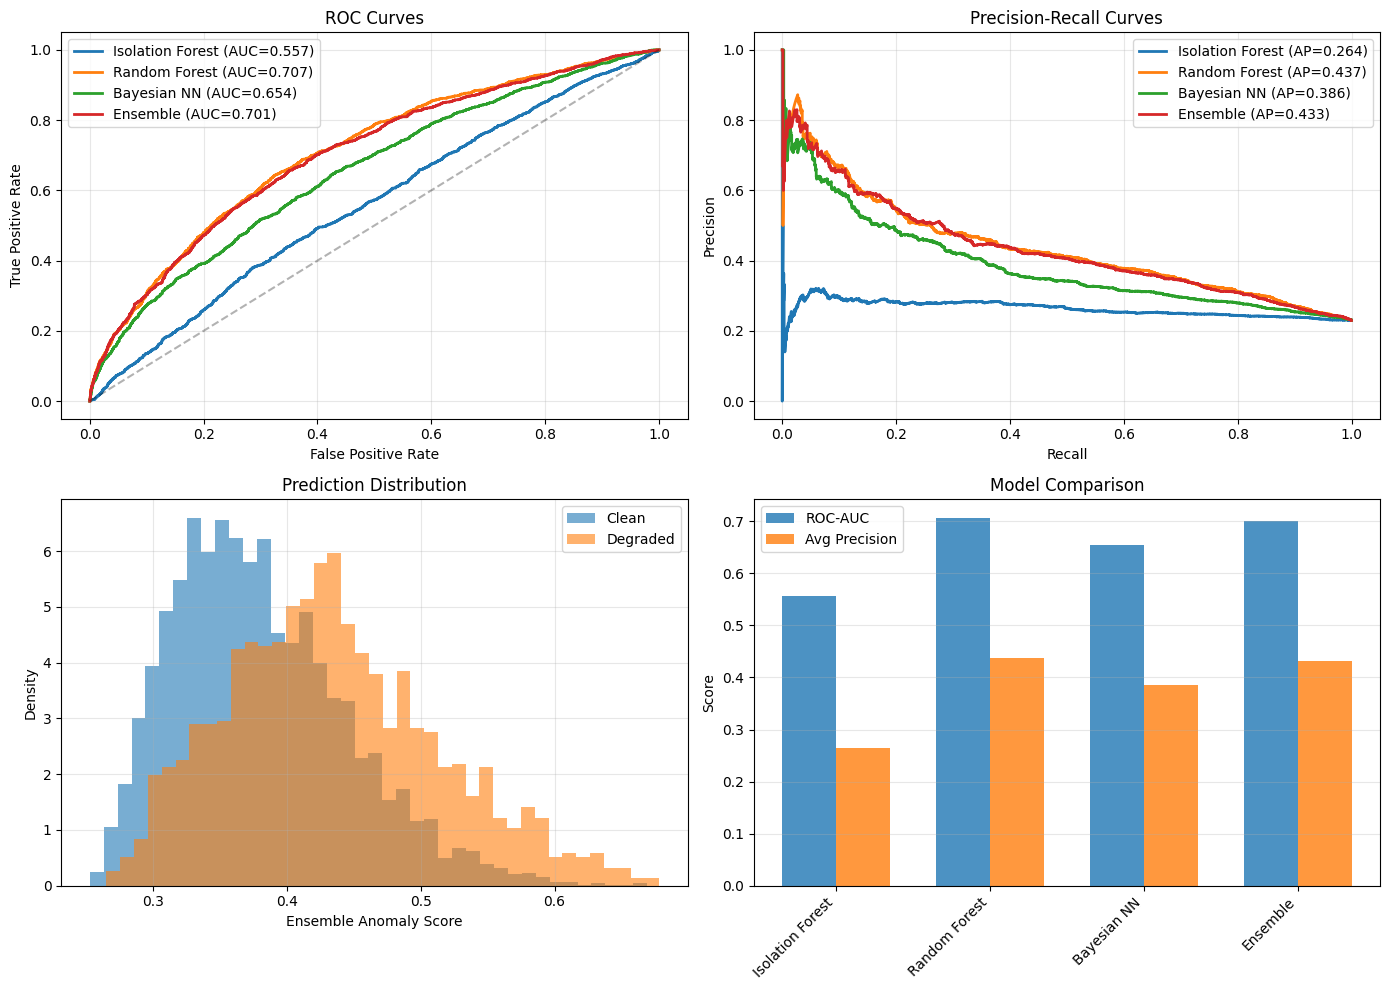

(      ecg_id  true_label  isolation_forest  random_forest  bayesian_nn  \
 0       1390           0          0.588568       0.305355     0.201665   
 1       4650           0          0.596826       0.283191     0.210494   
 2      17224           0          0.593504       0.179560     0.144129   
 3       6851           0          0.587934       0.247963     0.161426   
 4       6155           0          0.594439       0.162411     0.153173   
 ...      ...         ...               ...            ...          ...   
 6547    9100           0          0.614837       0.486514     0.390034   
 6548   18579           0          0.585579       0.256996     0.156255   
 6549    5671           0          0.595560       0.384827     0.178048   
 6550   18354           0          0.604008       0.366626     0.203726   
 6551    4938           0          0.594651       0.204735     0.193867   
 
       bayesian_nn_std  ensemble  
 0            0.041753  0.365196  
 1            0.051333  0.36

In [141]:
# =============================================================================
# Entry points (choose what to run)
# =============================================================================

if __name__ == "__main__":
    DATA_ROOT = Path("/Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/")

    # ---- OPTION 1: Run ONLY binary regression ----
    # opts = RunOptions(mode="fresh")  # rebuild features + refit trace
    # opts = RunOptions(mode="cache")  # use caches if present
    # mixed example: rebuild features but reuse trace (not typical, but allowed):
    # opts = RunOptions(mode="cache", use_cached_features=False, use_cached_trace=True)

    opts = RunOptions(mode="fresh")
    feat_df, trace, scaler, cols, preds, beta_summary = run_binary_regression_analysis(DATA_ROOT, opts)

# ---- OPTION 2: Run ONLY anomaly detection (using *current* features_df) ----
    # If you want anomaly detection to ALWAYS start from scratch: just rerun regression features in "fresh"
    # or load cached features with your preference before calling this.
    run_anomaly_detection(feat_df, out_dir=(DATA_ROOT / "anomaly_results"))

    # ---- OPTION 3: Run anomaly detection using cached feature file directly ----
    # feat_df_cached = pd.read_csv(DATA_ROOT / "features_quality.csv")
    # run_anomaly_detection(feat_df_cached, out_dir=(DATA_ROOT / "anomaly_results"))


# Deep learning

In [152]:
# =============================================================================
# Inception ECG Quality Pipeline (dtype fix + progress bars)
# =============================================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass
from typing import Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

from tqdm.auto import tqdm
import wfdb
import neurokit2 as nk
from scipy.signal import resample_poly


# =============================================================================
# Config
# =============================================================================

@dataclass
class IncCfg:
    data_root: Path
    db_csv: Path
    out_dir: Path

    use_hr: bool = True
    lead_index: int = 0
    fs_target: int = 100

    window_sec: int = 10
    batch_size: int = 64
    epochs: int = 20
    lr: float = 1e-3
    num_workers: int = 0  # notebook-safe


# =============================================================================
# Dataset
# =============================================================================

class PTBXLECGDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: IncCfg):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname = row["filename_hr"] if self.cfg.use_hr else row["filename_lr"]
        base = str(fname).replace(".hea", "").replace(".dat", "")

        sig, fields = wfdb.rdsamp(str(self.cfg.data_root / base))
        fs = float(fields["fs"])

        x = sig[:, self.cfg.lead_index].astype(np.float32)

        # neurokit sometimes returns float64 -> force float32 after cleaning
        x = nk.ecg_clean(x, sampling_rate=fs).astype(np.float32)

        # Resample if needed (resample_poly may output float64 -> cast back to float32)
        if fs != self.cfg.fs_target:
            x = resample_poly(x, self.cfg.fs_target, int(fs)).astype(np.float32)
            fs = float(self.cfg.fs_target)

        n = int(self.cfg.window_sec * fs)
        if len(x) > n:
            x = x[:n]
        else:
            x = np.pad(x, (0, n - len(x))).astype(np.float32)

        # Normalize (keep float32)
        x = x.astype(np.float32)
        x = (x - x.mean(dtype=np.float32)) / (x.std(dtype=np.float32) + np.float32(1e-6))

        x = torch.from_numpy(x[None, :]).to(torch.float32)  # (1, T) float32
        y = torch.tensor(int(row["y"]), dtype=torch.long)

        return x, y, idx


# =============================================================================
# Model
# =============================================================================

class InceptionBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.b1 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.b2 = nn.Conv1d(in_ch, out_ch, 5, padding=2)
        self.b3 = nn.Conv1d(in_ch, out_ch, 7, padding=3)

    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x)], dim=1)


class InceptionECG(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc1 = InceptionBlock(1, 16)   # -> 48 ch
        self.inc2 = InceptionBlock(48, 32)  # -> 96 ch
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(96, 2)

    def forward(self, x):
        x = F.relu(self.inc1(x))
        x = F.relu(self.inc2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)


# =============================================================================
# Training helpers
# =============================================================================

def train_one_epoch(model, loader, opt, device, epoch, total_epochs):
    model.train()
    total, n = 0.0, 0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [train]", leave=False)
    for xb, yb, _ in pbar:
        xb = xb.to(device).float()   # dtype guard
        yb = yb.to(device).long()

        opt.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        opt.step()

        total += float(loss.item()) * xb.size(0)
        n += xb.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total / max(n, 1)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    p_list, y_list = [], []

    pbar = tqdm(loader, desc="Validation", leave=False)
    for xb, yb, _ in pbar:
        xb = xb.to(device).float()   # dtype guard
        logits = model(xb)
        p = torch.softmax(logits, dim=1)[:, 1]
        p_list.append(p.cpu().numpy())
        y_list.append(yb.numpy())

    p = np.concatenate(p_list)
    y = np.concatenate(y_list)

    auc = roc_auc_score(y, p)
    ap = average_precision_score(y, p)

    yhat = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()

    return {
        "auc": auc,
        "ap": ap,
        "acc": (tp + tn) / max(tp + tn + fp + fn, 1),
        "sens": tp / max(tp + fn, 1),
        "spec": tn / max(tn + fp, 1),
    }


# =============================================================================
# Main runner
# =============================================================================

def run_inception_pipeline(cfg: IncCfg):
    cfg.out_dir.mkdir(exist_ok=True, parents=True)

    db = pd.read_csv(cfg.db_csv)

    # Labels: degraded if ANY noise flags are nonzero
    noise_cols = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems"]
    for c in noise_cols:
        if c not in db.columns:
            raise ValueError(f"Missing column in ptbxl_database.csv: {c}")

    db["y"] = db[noise_cols].fillna(0).ne(0).any(axis=1).astype(int)

    print("Loading PTB-XL database...")
    print(f"Total records: {len(db)}")
    print(f"Degraded: {int(db['y'].sum())} ({100*db['y'].mean():.1f}%)\n")

    train_df, test_df = train_test_split(db, test_size=0.3, stratify=db["y"], random_state=42)

    train_ds = PTBXLECGDataset(train_df, cfg)
    test_ds = PTBXLECGDataset(test_df, cfg)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Training on device:", device)

    model = InceptionECG().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    for epoch in tqdm(range(1, cfg.epochs + 1), desc="Training epochs"):
        tr_loss = train_one_epoch(model, train_loader, opt, device, epoch, cfg.epochs)
        metrics = eval_epoch(model, test_loader, device)
        print(f"Epoch {epoch:02d} | loss={tr_loss:.4f} | AUC={metrics['auc']:.3f} | AP={metrics['ap']:.3f}")

    torch.save(model.state_dict(), cfg.out_dir / "inception_ecg.pt")
    print("Saved model to:", cfg.out_dir / "inception_ecg.pt")


# =============================================================================
# Example usage
# =============================================================================

# if __name__ == "__main__":
#     DATA_ROOT = Path("/Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/")
#     cfg = IncCfg(
#         data_root=DATA_ROOT,
#         db_csv=DATA_ROOT / "ptbxl_database.csv",
#         out_dir=DATA_ROOT / "inception_quality_out",
#         use_hr=False,
#         lead_index=0,
#         fs_target=100,
#         num_workers=0,
#         epochs=20,
#         batch_size=64,
#     )
#     run_inception_pipeline(cfg)


In [153]:
# =============================================================================
# Example usage
# =============================================================================

if __name__ == "__main__":
    DATA_ROOT = Path("/Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/")
    cfg = IncCfg(
        data_root=DATA_ROOT,
        db_csv=DATA_ROOT / "ptbxl_database.csv",
        out_dir=DATA_ROOT / "inception_quality_out",
        use_hr=False,
        lead_index=0,
        fs_target=100,
        num_workers=0,
        epochs=20,
        batch_size=64,
    )
    run_inception_pipeline(cfg)

Loading PTB-XL database...
Total records: 21837
Degraded: 5021 (23.0%)

Training on device: cpu


Epoch 1/20 [train]: 100%|████████| 239/239 [04:14<00:00,  1.01it/s, loss=0.5612]
                                                                                
Training epochs:   5%|█▏                      | 1/20 [05:30<1:44:46, 330.85s/it]

Epoch 01 | loss=0.5406 | AUC=0.591 | AP=0.283



Epoch 2/20 [train]: 100%|████████| 239/239 [04:13<00:00,  1.05s/it, loss=0.5104]
                                                                                
Training epochs:  10%|██▍                     | 2/20 [11:00<1:38:58, 329.89s/it]

Epoch 02 | loss=0.5348 | AUC=0.614 | AP=0.308


...

Epoch 18 | loss=0.4921 | AUC=0.707 | AP=0.419



Epoch 19/20 [train]: 100%|███████| 239/239 [04:03<00:00,  1.05it/s, loss=0.5147]
                                                                                
Training epochs:  95%|█████████████████████▊ | 19/20 [1:44:10<05:18, 318.70s/it]

Epoch 19 | loss=0.4932 | AUC=0.706 | AP=0.418



Epoch 20/20 [train]: 100%|███████| 239/239 [04:04<00:00,  1.05it/s, loss=0.4530]
                                                                                
Training epochs: 100%|███████████████████████| 20/20 [1:49:30<00:00, 328.52s/it]

Epoch 20 | loss=0.4916 | AUC=0.707 | AP=0.420
Saved model to: /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/inception_quality_out/inception_ecg.pt


# TS2Vec

In [1]:
from pathlib import Path

# We'll stick to v3 name to keep your imports simple, or you can name it v4
module_path = Path("ptbxl_ssl_robust_v3.py")

module_code = r'''
from __future__ import annotations

import random
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Dict, Optional, List

import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, butter, filtfilt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    f1_score, 
    accuracy_score, 
    classification_report, 
    matthews_corrcoef
)
from tqdm.auto import tqdm


# ----------------------------
# Repro / Threads
# ----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def set_torch_threads(n: int = 6):
    try:
        if isinstance(n, int) and n > 0:
            torch.set_num_threads(n)
            torch.set_num_interop_threads(min(4, n))
    except RuntimeError:
        pass 


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =============================================================================
# Config
# =============================================================================
@dataclass
class Config:
    data_root: Path
    db_csv: Path
    out_dir: Path

    use_hr: bool = True
    input_channels: int = 12 

    fs_target: int = 100
    window_sec: int = 10

    batch_size: int = 64
    epochs: int = 30
    lr: float = 1e-4          
    weight_decay: float = 1e-4
    
    use_class_weights: bool = True 

    num_workers: int = 4
    torch_threads: int = 6

    emb_dim: int = 256
    
    seed: int = 42


# =============================================================================
# Labels + path resolve
# =============================================================================
def build_degradation_labels(db: pd.DataFrame) -> np.ndarray:
    noise_cols = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems"]
    missing = [c for c in noise_cols if c not in db.columns]
    if missing:
        print(f"Warning: Noise columns {missing} not found. Assuming clean.")
        return np.zeros(len(db))
    return db[noise_cols].fillna(0).ne(0).any(axis=1).astype(int).to_numpy()


def resolve_ptbxl_base(data_root: Path, fname: str) -> Path:
    rel = str(fname).replace("\\", "/").replace(".hea", "").replace(".dat", "")
    
    base = data_root / rel
    if base.with_suffix(".hea").exists():
        return base
        
    base2 = data_root / "records500" / rel
    if base2.with_suffix(".hea").exists():
        return base2
            
    parts = Path(rel).parts
    if len(parts) > 1:
        base3 = data_root / Path(*parts[1:])
        if base3.with_suffix(".hea").exists():
            return base3
            
    raise FileNotFoundError(f"Could not resolve record base for: {fname}")


# =============================================================================
# Dataset (Robust Version)
# =============================================================================
class PTBXLECGWindowDataset(Dataset):
    def __init__(self, df: pd.DataFrame, y: np.ndarray, cfg: Config, mode: str = "train"):
        self.df = df.reset_index(drop=True)
        self.y = y.astype(int)
        self.cfg = cfg
        self.mode = mode
        self.T = int(cfg.window_sec * cfg.fs_target)
        
        nyq = float(cfg.fs_target) / 2.0
        low = 0.5 / nyq
        high = min(40.0 / nyq, 0.99)
        self.b, self.a = butter(3, [low, high], btype='band')

    def __len__(self):
        return len(self.df)

    def _load_window(self, idx: int) -> np.ndarray:
        row = self.df.iloc[idx]
        fname = row["filename_hr"] if self.cfg.use_hr else row["filename_lr"]
        
        base = resolve_ptbxl_base(self.cfg.data_root, fname)
        sig, fields = wfdb.rdsamp(str(base))
        fs = float(fields.get("fs", 500.0))
        
        x = sig.T.astype(np.float32)

        if int(fs) != int(self.cfg.fs_target):
            x = resample_poly(x, self.cfg.fs_target, int(fs), axis=1).astype(np.float32)

        if x.shape[1] >= 10: 
            x = filtfilt(self.b, self.a, x, axis=1).astype(np.float32)
        
        if x.shape[1] > self.T:
            x = x[:, :self.T]
        elif x.shape[1] < self.T:
            pad_len = self.T - x.shape[1]
            x = np.pad(x, ((0, 0), (0, pad_len)), mode="constant").astype(np.float32)

        if np.std(x) < 1e-6:
            raise ValueError("Flatline signal")

        return x

    def __getitem__(self, idx: int):
        max_retries = 5
        attempts = 0
        current_idx = idx
        while attempts < max_retries:
            try:
                x = self._load_window(current_idx)
                means = x.mean(axis=1, keepdims=True)
                stds = x.std(axis=1, keepdims=True) + 1e-6
                x = (x - means) / stds
                return torch.from_numpy(x).float(), torch.tensor(int(self.y[current_idx]), dtype=torch.long)
            except (FileNotFoundError, IndexError, ValueError, RuntimeError):
                current_idx = np.random.randint(0, len(self.df))
                attempts += 1
        raise RuntimeError(f"Failed to load valid sample after {max_retries} retries")


# =============================================================================
# Encoder (ResNet-1D) + Classifier
# =============================================================================
class ResBlock1D(nn.Module):
    def __init__(self, ch: int, k: int = 7, dropout: float = 0.1):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(ch, ch, kernel_size=k, padding=pad)
        self.conv2 = nn.Conv1d(ch, ch, kernel_size=k, padding=pad)
        self.bn1 = nn.BatchNorm1d(ch)
        self.bn2 = nn.BatchNorm1d(ch)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        return F.relu(x + h)


class SupervisedModel(nn.Module):
    def __init__(self, in_ch: int = 12, emb_dim: int = 256, num_classes: int = 2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.layer1 = nn.Sequential(ResBlock1D(64, k=7), ResBlock1D(64, k=7))
        self.downsample1 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1)
        self.layer2 = nn.Sequential(ResBlock1D(128, k=7), ResBlock1D(128, k=7))
        self.downsample2 = nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1)
        self.layer3 = nn.Sequential(ResBlock1D(256, k=5), ResBlock1D(256, k=5))
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.2), 
            nn.Linear(256, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, num_classes)
        )

    def forward(self, x):
        h = self.stem(x)
        h = self.layer1(h)
        h = self.downsample1(h)
        h = self.layer2(h)
        h = self.downsample2(h)
        h = self.layer3(h)
        
        z = self.pool(h).squeeze(-1)
        logits = self.classifier(z)
        return logits


# =============================================================================
# Helper: Metrics Calculation
# =============================================================================
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        "auprc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0,
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

# =============================================================================
# Training Loop
# =============================================================================
def train_supervised(cfg: Config, train_loader: DataLoader, val_loader: DataLoader, class_weights: torch.Tensor):
    device = get_device()
    model = SupervisedModel(in_ch=cfg.input_channels, emb_dim=cfg.emb_dim, num_classes=2).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    
    # Standard scheduler without verbose argument
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=3
    )
    
    best_auprc = 0.0
    best_model_state = None
    early_stop_counter = 0
    patience_limit = 10 
    
    print(f"Device: {device}")
    print(f"Class Weights in Loss: {class_weights.tolist()}")

    for epoch in range(1, cfg.epochs + 1):
        # --- TRAIN ---
        model.train()
        train_loss = 0.0
        train_preds, train_targets = [], []
        
        for x, y in tqdm(train_loader, desc=f"Ep {epoch}/{cfg.epochs} [Train]", leave=False):
            x, y = x.to(device), y.to(device)
            
            opt.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            opt.step()
            
            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(y.cpu().numpy())
            
        avg_train_loss = train_loss / len(train_loader)
        train_f1 = f1_score(train_targets, train_preds, zero_division=0)

        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        val_preds, val_targets, val_probs = [], [], []
        
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"Ep {epoch} [Val]", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                
                probs = torch.softmax(logits, dim=1)[:, 1]
                preds = torch.argmax(logits, dim=1)
                
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(y.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        metrics = calculate_metrics(val_targets, val_preds, val_probs)
        
        scheduler.step(metrics['auprc'])
        
        if metrics['auprc'] > best_auprc:
            best_auprc = metrics['auprc']
            best_model_state = model.state_dict()
            early_stop_counter = 0
            saved_msg = "⭐ Saved"
        else:
            early_stop_counter += 1
            saved_msg = ""
            
        print(f"Ep {epoch:02d} | Train Loss: {avg_train_loss:.4f} F1: {train_f1:.3f} | "
              f"Val AUPRC: {metrics['auprc']:.4f} MCC: {metrics['mcc']:.4f} Loss: {avg_val_loss:.4f} {saved_msg}")

        if early_stop_counter >= patience_limit:
            print(f"⏹️ Early stopping triggered after {patience_limit} epochs without AUPRC improvement.")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)
        
    return model

# =============================================================================
# Orchestrator
# =============================================================================
def run_pipeline(cfg: Config):
    seed_everything(cfg.seed)
    set_torch_threads(cfg.torch_threads)
    cfg.out_dir.mkdir(exist_ok=True, parents=True)

    print("="*80)
    print("PTB-XL PIPELINE: SUPERVISED DEGRADATION DETECTION (ROBUST v3)")
    print("="*80)
    
    if not cfg.db_csv.exists():
        raise FileNotFoundError(f"Database not found: {cfg.db_csv}")
    
    db = pd.read_csv(cfg.db_csv)
    y = build_degradation_labels(db)
    
    n_total = len(y)
    n_deg = int(y.sum())
    n_clean = n_total - n_deg
    print(f"\n[Data Stats]")
    print(f"Total:    {n_total}")
    print(f"Clean:    {n_clean} ({n_clean/n_total:.1%})")
    print(f"Degraded: {n_deg} ({n_deg/n_total:.1%})")
    
    idx_train, idx_test = train_test_split(
        np.arange(n_total), test_size=0.2, stratify=y, random_state=cfg.seed
    )
    
    y_train_full = y[idx_train]
    idx_tr, idx_val = train_test_split(
        idx_train, test_size=0.2, stratify=y_train_full, random_state=cfg.seed
    )
    
    print(f"Train: {len(idx_tr)} | Val: {len(idx_val)} | Test: {len(idx_test)}")
    
    y_tr_labels = y[idx_tr]
    count_0 = (y_tr_labels == 0).sum()
    count_1 = (y_tr_labels == 1).sum()
    weight_0 = 1.0 
    weight_1 = count_0 / count_1 
    
    class_weights = torch.tensor([weight_0, weight_1]).float()
    
    ds_train = PTBXLECGWindowDataset(db.iloc[idx_tr], y[idx_tr], cfg, mode="train")
    ds_val   = PTBXLECGWindowDataset(db.iloc[idx_val], y[idx_val], cfg, mode="eval")
    ds_test  = PTBXLECGWindowDataset(db.iloc[idx_test], y[idx_test], cfg, mode="eval")
    
    train_loader = DataLoader(ds_train, batch_size=cfg.batch_size, shuffle=True, 
                              num_workers=cfg.num_workers, drop_last=True)
    val_loader   = DataLoader(ds_val, batch_size=cfg.batch_size, shuffle=False, 
                              num_workers=cfg.num_workers)
    test_loader  = DataLoader(ds_test, batch_size=cfg.batch_size, shuffle=False, 
                              num_workers=cfg.num_workers)
    
    print("\nStarting Training...")
    model = train_supervised(cfg, train_loader, val_loader, class_weights)
    
    # --- NEW: SAVE THE MODEL TO DISK ---
    model_path = cfg.out_dir / "best_model.pt"
    torch.save(model.state_dict(), model_path)
    print(f"✅ Model saved to {model_path}")
    
    print("\n" + "="*80)
    print("FINAL TEST EVALUATION")
    print("="*80)
    
    device = get_device()
    model.eval()
    
    # Define criterion for test loss calculation
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    
    all_preds, all_targets, all_probs = [], [], []
    test_loss = 0.0
    
    with torch.no_grad():
        for x, y_batch in tqdm(test_loader, desc="Testing"):
            x, y_batch = x.to(device), y_batch.to(device)
            
            logits = model(x)
            loss = criterion(logits, y_batch)
            test_loss += loss.item()
            
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_test_loss = test_loss / len(test_loader)
            
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=["Clean", "Degraded"]))
    
    metrics = calculate_metrics(all_targets, all_preds, all_probs)
    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"AUC:       {metrics['auc']:.4f}")
    print(f"AUPRC:     {metrics['auprc']:.4f} (Crucial for Imbalance)")
    print(f"MCC:       {metrics['mcc']:.4f}")
    
    return metrics
'''

# Write the file
module_path.write_text(module_code, encoding="utf-8")
print(f"Wrote module to: {module_path.resolve()}")

Wrote module to: /Users/reubenaddison/Desktop/GA_Tech/Spring 2026_GT/Projects/ptbxl_ssl_robust_v3.py


/opt/anaconda3/envs/jax_gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Found database at /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/ptbxl_database.csv
🚀 Starting Pipeline...
PTB-XL PIPELINE: SUPERVISED DEGRADATION DETECTION (ROBUST v3)

[Data Stats]
Total:    21837
Clean:    16816 (77.0%)
Degraded: 5021 (23.0%)
Train: 13975 | Val: 3494 | Test: 4368

Starting Training...
Device: cpu
Class Weights in Loss: [1.0, 3.3481643199920654]


Ep 01 | Train Loss: 0.6679 F1: 0.393 | Val AUPRC: 0.4002 MCC: 0.2145 Loss: 0.6485 ⭐ Saved


Ep 02 | Train Loss: 0.6299 F1: 0.461 | Val AUPRC: 0.4423 MCC: 0.2719 Loss: 0.6263 ⭐ Saved


Ep 03 | Train Loss: 0.6061 F1: 0.478 | Val AUPRC: 0.4409 MCC: 0.2907 Loss: 0.6148 


...

Ep 17 | Train Loss: 0.2950 F1: 0.750 | Val AUPRC: 0.4399 MCC: 0.2934 Loss: 0.9075 


Ep 18 | Train Loss: 0.2389 F1: 0.791 | Val AUPRC: 0.4318 MCC: 0.2867 Loss: 1.0039 


Ep 19 | Train Loss: 0.2186 F1: 0.812 | Val AUPRC: 0.4517 MCC: 0.3127 Loss: 1.0344 
⏹️ Early stopping triggered after 10 epochs without AUPRC improvement.
✅ Model saved to ssl_experiments_v3/best_model.pt

FINAL TEST EVALUATION


Testing: 100%|██████████████████████████████████| 69/69 [02:52<00:00,  2.51s/it]



Classification Report:
              precision    recall  f1-score   support

       Clean       0.86      0.74      0.79      3364
    Degraded       0.41      0.60      0.48      1004

    accuracy                           0.71      4368
   macro avg       0.63      0.67      0.64      4368
weighted avg       0.76      0.71      0.72      4368

Test Loss: 1.0557
AUC:       0.7246
AUPRC:     0.4367 (Crucial for Imbalance)
MCC:       0.2994

✅ Training Complete. Model Saved.

📊 Generating Plots from Saved Model...


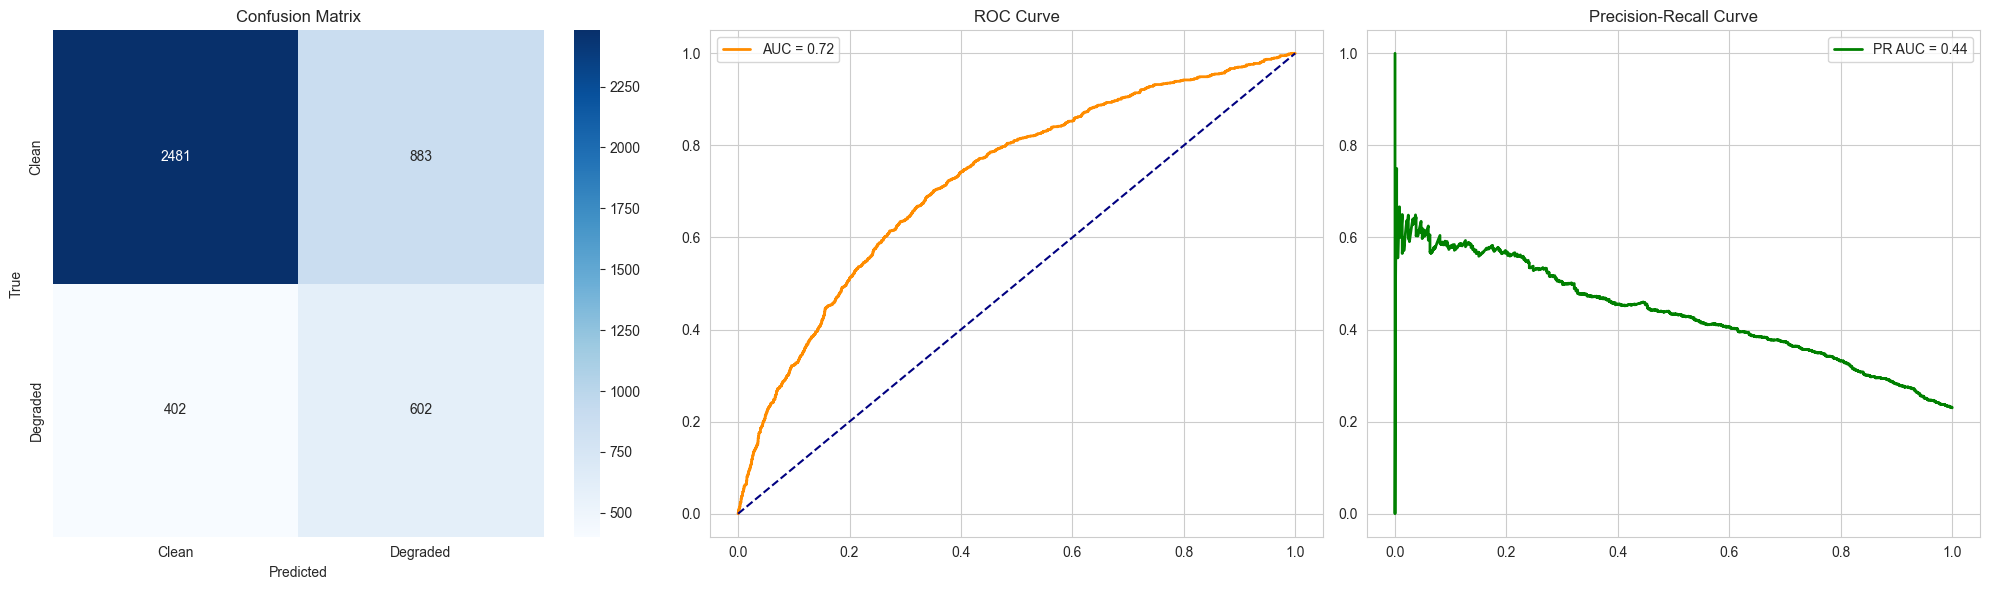

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from torch.utils.data import DataLoader

# Add current directory to path
if "." not in sys.path:
    sys.path.append(".")

# IMPORT THE ROBUST V3 MODULE
import ptbxl_ssl_robust_v3 as ptbxl

# ==========================================
# 1. SETUP PATHS
# ==========================================
DATA_ROOT = Path("/Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/")
DB_CSV = DATA_ROOT / "ptbxl_database.csv"
OUT_DIR = Path("ssl_experiments_v3")

if not DB_CSV.exists():
    print(f"❌ Error: Could not find database at {DB_CSV}")
else:
    print(f"✅ Found database at {DB_CSV}")

    # ==========================================
    # 2. CONFIGURE & TRAIN
    # ==========================================
    cfg = ptbxl.Config(
        data_root=DATA_ROOT,
        db_csv=DB_CSV,
        out_dir=OUT_DIR,
        input_channels=12,
        epochs=30,
        batch_size=64,
        lr=1e-4,
        num_workers=4,
        torch_threads=6,
        seed=42
    )

    print(f"🚀 Starting Pipeline...")
    
    try:
        # --- PHASE 1: TRAIN & SAVE ---
        # This trains the model and saves 'best_model.pt' to OUT_DIR
        metrics = ptbxl.run_pipeline(cfg)
        print("\n✅ Training Complete. Model Saved.")
        
        # --- PHASE 2: VISUALIZATION ---
        print("\n📊 Generating Plots from Saved Model...")
        
        # 1. Re-load Data (Must match seed=42 used in pipeline)
        ptbxl.seed_everything(cfg.seed)
        db = pd.read_csv(cfg.db_csv)
        y = ptbxl.build_degradation_labels(db)
        
        # Re-create Test Split
        idx_train, idx_test = train_test_split(
            np.arange(len(y)), test_size=0.2, stratify=y, random_state=cfg.seed
        )
        
        # Create Test Loader
        ds_test = ptbxl.PTBXLECGWindowDataset(db.iloc[idx_test], y[idx_test], cfg, mode="eval")
        test_loader = DataLoader(ds_test, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
        
        # 2. Load the Best Model from Disk
        device = ptbxl.get_device()
        model = ptbxl.SupervisedModel(in_ch=12, emb_dim=256, num_classes=2).to(device)
        model_path = cfg.out_dir / "best_model.pt"
        
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        
        # 3. Get Predictions
        all_targets, all_probs, all_preds = [], [], []
        
        with torch.no_grad():
            for x, y_batch in test_loader:
                x = x.to(device)
                logits = model(x)
                probs = torch.softmax(logits, dim=1)[:, 1]
                preds = torch.argmax(logits, dim=1)
                
                all_targets.extend(y_batch.numpy())
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
        
        # 4. Plot
        sns.set_style("whitegrid")
        fig, ax = plt.subplots(1, 3, figsize=(20, 6))

        # Confusion Matrix
        cm = confusion_matrix(all_targets, all_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
        ax[0].set_title("Confusion Matrix")
        ax[0].set_xlabel("Predicted")
        ax[0].set_ylabel("True")
        ax[0].set_xticklabels(['Clean', 'Degraded'])
        ax[0].set_yticklabels(['Clean', 'Degraded'])

        # ROC Curve
        fpr, tpr, _ = roc_curve(all_targets, all_probs)
        roc_auc = auc(fpr, tpr)
        ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
        ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
        ax[1].set_title("ROC Curve")
        ax[1].legend()

        # PR Curve
        prec, rec, _ = precision_recall_curve(all_targets, all_probs)
        pr_auc = auc(rec, prec)
        ax[2].plot(rec, prec, color='green', lw=2, label=f'PR AUC = {pr_auc:.2f}')
        ax[2].set_title("Precision-Recall Curve")
        ax[2].legend()

        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()

# V2 - deep learning 

In [1]:
from pathlib import Path

module_path = Path("ptbxl_supervised_v5.py")

module_code = r'''
from __future__ import annotations

import random
import sys
import copy
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Dict, Optional, List

import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, butter, filtfilt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    f1_score, 
    accuracy_score, 
    classification_report, 
    matthews_corrcoef,
    confusion_matrix
)
from tqdm.auto import tqdm

# ----------------------------
# 1. Reproducibility & Setup
# ----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

@dataclass
class Config:
    data_root: Path
    db_csv: Path
    out_dir: Path

    # Data Params
    use_hr: bool = True
    input_channels: int = 12 
    fs_target: int = 100
    window_sec: int = 10
    
    # Training Params
    batch_size: int = 64
    epochs: int = 40        # Increased epochs (regularization slows convergence)
    lr: float = 1e-4        # Conservative learning rate
    
    # REGULARIZATION (The Fix for Overfitting)
    weight_decay: float = 1e-2  # Stronger L2 penalty
    dropout: float = 0.5        # Aggressive dropout
    patience: int = 8           # Early stopping patience

    num_workers: int = 4
    torch_threads: int = 6
    emb_dim: int = 256
    seed: int = 42

# ----------------------------
# 2. Robust Labeling & Pathing
# ----------------------------
def build_degradation_labels(db: pd.DataFrame) -> np.ndarray:
    """
    Parses PTB-XL quality labels. 
    Returns 1 if ANY degradation column is non-empty/non-zero.
    """
    noise_cols = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems"]
    missing = [c for c in noise_cols if c not in db.columns]
    if missing:
        print(f"Warning: Columns {missing} missing. Assuming clean.")
        return np.zeros(len(db), dtype=int)
    
    def is_noisy(row):
        for c in noise_cols:
            val = row[c]
            # Check for strings (PTB-XL specific) or non-zero numbers
            if pd.notna(val) and str(val).lower() not in ['nan', '']:
                return 1
        return 0
        
    return db.apply(is_noisy, axis=1).to_numpy()

def resolve_ptbxl_base(data_root: Path, fname: str) -> Path:
    if pd.isna(fname): raise FileNotFoundError("Filename is NaN")
    rel = str(fname).replace("\\", "/").replace(".hea", "").replace(".dat", "")
    
    # Robust search paths
    candidates = [
        data_root / rel,
        data_root / "records500" / rel,
        data_root / "records100" / rel,
        data_root / rel.split('/')[-1]
    ]
    parts = Path(rel).parts
    if len(parts) > 1:
        candidates.append(data_root / Path(*parts[1:]))

    for base in candidates:
        if base.with_suffix(".hea").exists():
            return base
            
    raise FileNotFoundError(f"Record not found: {fname}")

# ----------------------------
# 3. Dataset with Noise Augmentation
# ----------------------------
class PTBXLECGWindowDataset(Dataset):
    def __init__(self, df: pd.DataFrame, y: np.ndarray, cfg: Config, mode: str = "train"):
        self.df = df.reset_index(drop=True)
        self.y = y.astype(int)
        self.cfg = cfg
        self.mode = mode
        self.T = int(cfg.window_sec * cfg.fs_target)
        
        # Filter setup
        nyq = float(cfg.fs_target) / 2.0
        self.b, self.a = butter(3, [0.5/nyq, 40.0/nyq], btype='band')

    def __len__(self):
        return len(self.df)

    def _augment(self, x: np.ndarray) -> np.ndarray:
        """
        Apply noise/masking to force model to learn robustness.
        Crucial for preventing overfitting on clean signals.
        """
        # 1. Channel Mask (Simulate loose electrode) - 30% prob
        if np.random.rand() < 0.3:
            c_idx = np.random.randint(0, x.shape[0])
            x[c_idx, :] = 0.0

        # 2. Gaussian Noise (Simulate static) - 30% prob
        if np.random.rand() < 0.3:
            noise_level = np.random.uniform(0.01, 0.05)
            noise = np.random.normal(0, noise_level, x.shape).astype(np.float32)
            x = x + noise
            
        return x

    def _load_window(self, idx: int) -> np.ndarray:
        row = self.df.iloc[idx]
        fname = row["filename_hr"] if self.cfg.use_hr else row["filename_lr"]
        base = resolve_ptbxl_base(self.cfg.data_root, fname)
        
        sig, fields = wfdb.rdsamp(str(base))
        fs = float(fields.get("fs", 500.0))
        x = sig.T.astype(np.float32) # [Channels, Time]

        # Resample
        if int(fs) != int(self.cfg.fs_target):
            x = resample_poly(x, self.cfg.fs_target, int(fs), axis=1).astype(np.float32)

        # Filter (Safe)
        if x.shape[1] >= 10:
            x = filtfilt(self.b, self.a, x, axis=1).astype(np.float32)
        
        # Pad/Crop
        if x.shape[1] > self.T:
            x = x[:, :self.T]
        elif x.shape[1] < self.T:
            pad_len = self.T - x.shape[1]
            x = np.pad(x, ((0, 0), (0, pad_len)), mode="constant")
            
        return x

    def __getitem__(self, idx: int):
        retries = 0
        current_idx = idx
        while retries < 5:
            try:
                x = self._load_window(current_idx)
                
                # Check for dead signal
                if np.std(x) < 1e-6: raise ValueError("Flatline")
                
                # Normalize (Standard Score)
                x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-6)
                
                # Augment ONLY if training
                if self.mode == "train":
                    x = self._augment(x)
                    
                return torch.from_numpy(x).float(), torch.tensor(int(self.y[current_idx]), dtype=torch.long)
                
            except Exception:
                current_idx = np.random.randint(0, len(self.df))
                retries += 1
                
        raise RuntimeError("Failed to load valid sample.")

# ----------------------------
# 4. Model: ResNet1D + SE Attention
# ----------------------------
class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block to learn Channel Attention."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y

class ResBlock1D(nn.Module):
    def __init__(self, ch: int, k: int = 7, dropout: float = 0.1):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(ch, ch, kernel_size=k, padding=pad)
        self.bn1 = nn.BatchNorm1d(ch)
        self.conv2 = nn.Conv1d(ch, ch, kernel_size=k, padding=pad)
        self.bn2 = nn.BatchNorm1d(ch)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        return F.relu(x + h)

class SupervisedModelV5(nn.Module):
    def __init__(self, in_ch: int = 12, emb_dim: int = 256, dropout: float = 0.5):
        super().__init__()
        
        # Stem
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        
        # ResNet Backbone
        self.layer1 = nn.Sequential(ResBlock1D(64), ResBlock1D(64))
        self.down1 = nn.Conv1d(64, 128, 3, 2, 1)
        
        self.layer2 = nn.Sequential(ResBlock1D(128), ResBlock1D(128))
        self.down2 = nn.Conv1d(128, 256, 3, 2, 1)
        
        self.layer3 = nn.Sequential(ResBlock1D(256), ResBlock1D(256))
        
        # Attention Mechanism (New in v5)
        self.attn = SEBlock(256)
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        # Classifier with Aggressive Dropout
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim, 2)
        )

    def forward(self, x):
        h = self.stem(x)
        h = self.down1(self.layer1(h))
        h = self.down2(self.layer2(h))
        h = self.layer3(h)
        
        # Apply Attention
        h = self.attn(h)
        
        z = self.pool(h).squeeze(-1)
        return self.classifier(z)

# ----------------------------
# 5. Training Logic (Sampler Enabled)
# ----------------------------
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auprc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0,
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

def train_model(cfg: Config, train_loader: DataLoader, val_loader: DataLoader):
    device = get_device()
    model = SupervisedModelV5(in_ch=cfg.input_channels, emb_dim=cfg.emb_dim, dropout=cfg.dropout).to(device)
    
    # Standard CrossEntropy (Sampler handles balance now)
    criterion = nn.CrossEntropyLoss()
    
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    
    best_auprc = 0.0
    best_state = None
    patience_counter = 0
    
    print(f"Start Training on {device} (Weighted Sampling Enabled)")
    
    for epoch in range(1, cfg.epochs + 1):
        # TRAIN
        model.train()
        train_loss = 0.0
        
        for x, y in tqdm(train_loader, desc=f"Ep {epoch} [Train]", leave=False):
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            opt.step()
            train_loss += loss.item()
            
        avg_tr_loss = train_loss / len(train_loader)
        
        # VAL
        model.eval()
        val_loss = 0.0
        all_y, all_pred, all_prob = [], [], []
        
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc=f"Ep {epoch} [Val]", leave=False):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                
                probs = torch.softmax(logits, dim=1)[:, 1]
                preds = torch.argmax(logits, dim=1)
                
                all_y.extend(y.cpu().numpy())
                all_pred.extend(preds.cpu().numpy())
                all_prob.extend(probs.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        metrics = calculate_metrics(all_y, all_pred, all_prob)
        
        # Logging
        scheduler.step(metrics['auprc'])
        save_msg = ""
        
        if metrics['auprc'] > best_auprc:
            best_auprc = metrics['auprc']
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            save_msg = "⭐ Best"
        else:
            patience_counter += 1
            
        print(f"Ep {epoch:02d} | TrLoss: {avg_tr_loss:.4f} | ValLoss: {avg_val_loss:.4f} | "
              f"AUPRC: {metrics['auprc']:.4f} MCC: {metrics['mcc']:.4f} {save_msg}")
              
        if patience_counter >= cfg.patience:
            print(f"⏹️ Early stopping at epoch {epoch}")
            break
            
    if best_state:
        model.load_state_dict(best_state)
    return model

# ----------------------------
# 6. Pipeline Execution
# ----------------------------
def run_v5_pipeline():
    # 1. Setup
    cfg = Config(
        data_root=Path("ptb-xl-1.0.3/"),
        db_csv=Path("ptb-xl-1.0.3/ptbxl_database.csv"),
        out_dir=Path("experiments/v5_supervised")
    )
    seed_everything(cfg.seed)
    cfg.out_dir.mkdir(parents=True, exist_ok=True)
    
    # 2. Data Loading
    print("Loading Database...")
    if not cfg.db_csv.exists(): raise FileNotFoundError("DB CSV missing")
    
    db = pd.read_csv(cfg.db_csv)
    y = build_degradation_labels(db)
    
    # Stats
    n_deg = y.sum()
    print(f"Clean: {len(y)-n_deg}, Degraded: {n_deg} ({n_deg/len(y):.1%})")
    
    # 3. Splits
    idx_all = np.arange(len(y))
    idx_train, idx_test = train_test_split(idx_all, test_size=0.2, stratify=y, random_state=cfg.seed)
    y_train_full = y[idx_train]
    idx_tr, idx_val = train_test_split(idx_train, test_size=0.2, stratify=y_train_full, random_state=cfg.seed)
    
    print(f"Train: {len(idx_tr)}, Val: {len(idx_val)}, Test: {len(idx_test)}")
    
    # 4. DataLoaders with SAMPLER
    ds_tr = PTBXLECGWindowDataset(db.iloc[idx_tr], y[idx_tr], cfg, mode="train")
    ds_val = PTBXLECGWindowDataset(db.iloc[idx_val], y[idx_val], cfg, mode="eval")
    ds_test = PTBXLECGWindowDataset(db.iloc[idx_test], y[idx_test], cfg, mode="eval")
    
    # Calculate Sampler Weights
    y_tr_indices = y[idx_tr]
    class_counts = np.bincount(y_tr_indices)
    class_weights = 1. / class_counts
    sample_weights = class_weights[y_tr_indices]
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).double(),
        num_samples=len(sample_weights),
        replacement=True
    )
    
    train_loader = DataLoader(ds_tr, batch_size=cfg.batch_size, sampler=sampler, num_workers=cfg.num_workers, drop_last=True)
    val_loader = DataLoader(ds_val, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(ds_test, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    
    # 5. Run
    model = train_model(cfg, train_loader, val_loader)
    
    # 6. Final Eval
    torch.save(model.state_dict(), cfg.out_dir / "best_model_v5.pt")
    
    print("\n=== FINAL TEST EVALUATION ===")
    model.eval()
    all_y, all_pred, all_prob = [], [], []
    device = get_device()
    
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="Test"):
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            all_y.extend(y.numpy())
            all_pred.extend(preds.cpu().numpy())
            all_prob.extend(probs.cpu().numpy())
            
    print(classification_report(all_y, all_pred, target_names=["Clean", "Degraded"]))
    metrics = calculate_metrics(all_y, all_pred, all_prob)
    print(f"AUPRC: {metrics['auprc']:.4f}")
    print(f"MCC:   {metrics['mcc']:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_y, all_pred))

if __name__ == "__main__":
    run_v5_pipeline()
'''

module_path.write_text(module_code, encoding="utf-8")
print(f"Wrote v5 module to: {module_path.resolve()}")

Wrote v5 module to: /Users/reubenaddison/Desktop/GA_Tech/Spring 2026_GT/Projects/ptbxl_supervised_v5.py


/opt/anaconda3/envs/jax_gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Found database at /Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/ptbxl_database.csv
🚀 Starting Pipeline V5...
Start Training on cpu (Weighted Sampling Enabled)


Ep 01 | TrLoss: 0.6688 | ValLoss: 0.5612 | AUPRC: 0.4258 MCC: 0.2609 ⭐ Best


Ep 02 | TrLoss: 0.6289 | ValLoss: 0.5410 | AUPRC: 0.4378 MCC: 0.2890 ⭐ Best


Ep 03 | TrLoss: 0.6040 | ValLoss: 0.6817 | AUPRC: 0.4283 MCC: 0.2847 


...

Ep 16 | TrLoss: 0.3213 | ValLoss: 0.6662 | AUPRC: 0.4532 MCC: 0.2883 


Ep 17 | TrLoss: 0.2761 | ValLoss: 0.7812 | AUPRC: 0.4550 MCC: 0.3313 


Ep 18 | TrLoss: 0.2503 | ValLoss: 0.7251 | AUPRC: 0.4095 MCC: 0.2543 


Ep 19 | TrLoss: 0.2314 | ValLoss: 0.8200 | AUPRC: 0.4599 MCC: 0.3404 


Ep 20 | TrLoss: 0.2198 | ValLoss: 0.9234 | AUPRC: 0.4286 MCC: 0.2899 
⏹️ Early stopping at epoch 20

✅ Training Complete. Model Saved to experiments/v5_supervised/best_model_v5.pt

📊 Generating Plots from Saved Model...


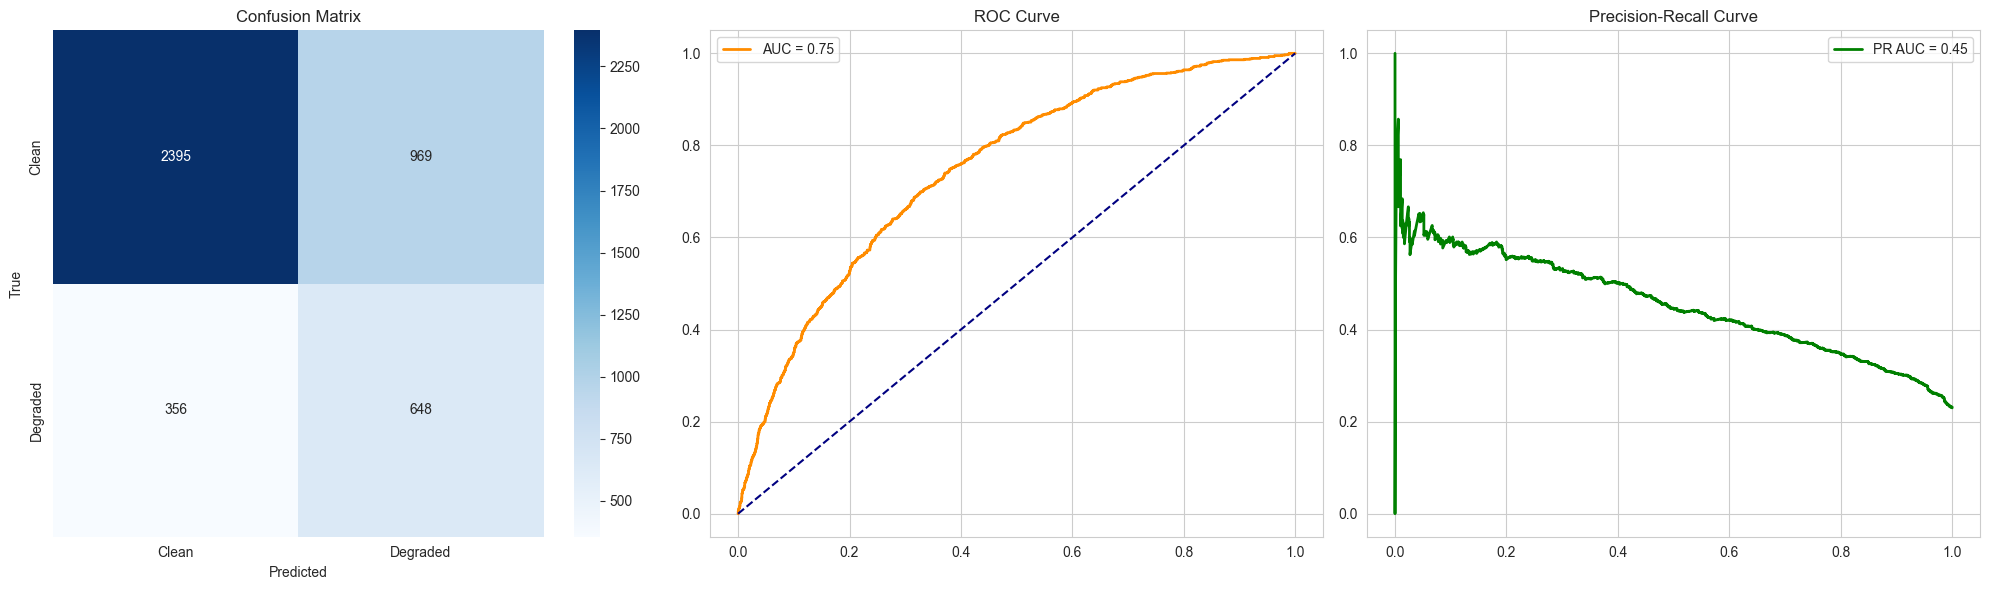

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from torch.utils.data import DataLoader, WeightedRandomSampler

# Add current directory to path
if "." not in sys.path:
    sys.path.append(".")

# IMPORT THE ROBUST V5 MODULE
# Ensure the file 'ptbxl_supervised_v5.py' is in this directory
import ptbxl_supervised_v5 as ptbxl  

# ==========================================
# 1. SETUP PATHS
# ==========================================
# Update this path to where your PTB-XL folder is located
DATA_ROOT = Path("/Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/")
DB_CSV = DATA_ROOT / "ptbxl_database.csv"
OUT_DIR = Path("experiments/v5_supervised")

if not DB_CSV.exists():
    print(f"❌ Error: Could not find database at {DB_CSV}")
else:
    print(f"✅ Found database at {DB_CSV}")

    # ==========================================
    # 2. CONFIGURE & TRAIN
    # ==========================================
    # We update the Config to match V5 requirements (dropout, patience, etc.)
    cfg = ptbxl.Config(
        data_root=DATA_ROOT,
        db_csv=DB_CSV,
        out_dir=OUT_DIR,
        input_channels=12,
        fs_target=100,
        window_sec=10,
        batch_size=64,
        epochs=40,        # V5 Standard
        lr=1e-4,          # V5 Standard
        weight_decay=1e-2, # V5 Regularization
        dropout=0.5,      # V5 Regularization
        patience=8,       # V5 Early Stopping
        num_workers=8,
        torch_threads=8,
        emb_dim=256,
        seed=42
    )

    print(f"🚀 Starting Pipeline V5...")
    
    try:
        # --- PHASE 1: PREPARE DATA ---
        ptbxl.seed_everything(cfg.seed)
        cfg.out_dir.mkdir(parents=True, exist_ok=True)
        
        # Load DB
        db = pd.read_csv(cfg.db_csv)
        y = ptbxl.build_degradation_labels(db)
        
        # Create Splits (Train/Val/Test)
        idx_all = np.arange(len(y))
        idx_train, idx_test = train_test_split(idx_all, test_size=0.2, stratify=y, random_state=cfg.seed)
        
        y_train_full = y[idx_train]
        idx_tr, idx_val = train_test_split(idx_train, test_size=0.2, stratify=y_train_full, random_state=cfg.seed)

        # Create Datasets
        # Note: Train set gets mode="train" for augmentation
        ds_tr = ptbxl.PTBXLECGWindowDataset(db.iloc[idx_tr], y[idx_tr], cfg, mode="train")
        ds_val = ptbxl.PTBXLECGWindowDataset(db.iloc[idx_val], y[idx_val], cfg, mode="eval")
        
        # --- V5 CRITICAL: SAMPLER SETUP ---
        # Calculate weights to balance the batches 50/50
        y_tr_indices = y[idx_tr]
        class_counts = np.bincount(y_tr_indices)
        sample_weights = 1. / class_counts[y_tr_indices]
        
        sampler = WeightedRandomSampler(
            weights=torch.from_numpy(sample_weights).double(),
            num_samples=len(sample_weights),
            replacement=True
        )

        # Create Loaders
        train_loader = DataLoader(ds_tr, batch_size=cfg.batch_size, sampler=sampler, num_workers=cfg.num_workers, drop_last=True)
        val_loader = DataLoader(ds_val, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

        # --- PHASE 2: TRAIN ---
        # We call the training function from the module
        model = ptbxl.train_model(cfg, train_loader, val_loader)
        
        # Save explicitly (train_model also saves best checkpoint, but we save final here too)
        model_path = cfg.out_dir / "best_model_v5.pt"
        torch.save(model.state_dict(), model_path)
        print(f"\n✅ Training Complete. Model Saved to {model_path}")
        
        # --- PHASE 3: VISUALIZATION ---
        print("\n📊 Generating Plots from Saved Model...")
        
        # 1. Load Test Data
        ds_test = ptbxl.PTBXLECGWindowDataset(db.iloc[idx_test], y[idx_test], cfg, mode="eval")
        test_loader = DataLoader(ds_test, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
        
        # 2. Get Predictions
        device = ptbxl.get_device()
        model.eval()
        
        all_targets, all_probs, all_preds = [], [], []
        
        with torch.no_grad():
            for x, y_batch in test_loader:
                x = x.to(device)
                logits = model(x)
                probs = torch.softmax(logits, dim=1)[:, 1]
                preds = torch.argmax(logits, dim=1)
                
                all_targets.extend(y_batch.numpy())
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
        
        # 3. Plot
        sns.set_style("whitegrid")
        fig, ax = plt.subplots(1, 3, figsize=(20, 6))

        # Confusion Matrix
        cm = confusion_matrix(all_targets, all_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
        ax[0].set_title("Confusion Matrix")
        ax[0].set_xlabel("Predicted")
        ax[0].set_ylabel("True")
        ax[0].set_xticklabels(['Clean', 'Degraded'])
        ax[0].set_yticklabels(['Clean', 'Degraded'])

        # ROC Curve
        fpr, tpr, _ = roc_curve(all_targets, all_probs)
        roc_auc = auc(fpr, tpr)
        ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
        ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
        ax[1].set_title("ROC Curve")
        ax[1].legend()

        # PR Curve
        prec, rec, _ = precision_recall_curve(all_targets, all_probs)
        pr_auc = auc(rec, prec)
        ax[2].plot(rec, prec, color='green', lw=2, label=f'PR AUC = {pr_auc:.2f}')
        ax[2].set_title("Precision-Recall Curve")
        ax[2].legend()

        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()

In [4]:
import numpy as np
import torch
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, matthews_corrcoef

def generate_report(model, test_loader, device):
    """
    Runs the model on the test_loader and prints the full classification report
    and metrics (AUC, AUPRC, MCC).
    """
    model.eval()
    all_targets = []
    all_preds = []
    all_probs = []
    
    # 1. Gather all predictions
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1] # Probability of "Degraded"
            preds = torch.argmax(logits, dim=1)        # 0 or 1
            
            all_targets.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # 2. Generate Classification Report
    print("\n" + "="*60)
    print("FINAL TEST EVALUATION")
    print("="*60)
    
    # This generates the table you showed
    print("Classification Report:")
    print(classification_report(all_targets, all_preds, target_names=["Clean", "Degraded"]))
    
    # 3. Calculate Extra Metrics
    auc = roc_auc_score(all_targets, all_probs)
    auprc = average_precision_score(all_targets, all_probs)
    mcc = matthews_corrcoef(all_targets, all_preds)
    
    print(f"AUC:       {auc:.4f}")
    print(f"AUPRC:     {auprc:.4f} (Crucial for Imbalance)")
    print(f"MCC:       {mcc:.4f}")
    
    return all_targets, all_preds, all_probs

# Usage Example:
generate_report(model, test_loader, device)


FINAL TEST EVALUATION
Classification Report:
              precision    recall  f1-score   support

       Clean       0.87      0.71      0.78      3364
    Degraded       0.40      0.65      0.49      1004

    accuracy                           0.70      4368
   macro avg       0.64      0.68      0.64      4368
weighted avg       0.76      0.70      0.72      4368

AUC:       0.7473
AUPRC:     0.4548 (Crucial for Imbalance)
MCC:       0.3114


([np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64


🏆 OPTIMAL THRESHOLD ANALYSIS
Best Threshold: 0.5708
Best F1 Score:  0.5245
Precision at Best: 0.4351
Recall at Best:    0.6600

🛡️ SAFETY THRESHOLD (Target Precision >= 0.40)
Threshold: 0.3784
Recall:    0.7410


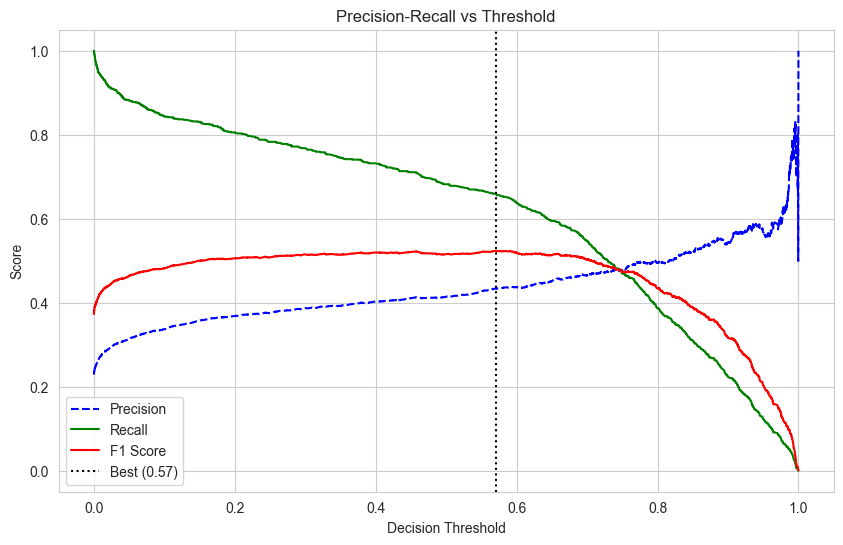

In [6]:
def evaluate_with_optimal_threshold(model, loader, device, threshold=0.38):
    """
    Evaluate model using custom threshold instead of default 0.5
    """
    model.eval()
    all_y, all_probs = [], []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]
            
            all_y.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_y = np.array(all_y)
    all_probs = np.array(all_probs)
    
    # Apply custom threshold
    all_preds = (all_probs >= threshold).astype(int)
    
    # Calculate metrics
    from sklearn.metrics import classification_report, confusion_matrix
    
    print(f"\n🎯 EVALUATION AT THRESHOLD = {threshold:.4f}")
    print(classification_report(all_y, all_preds, target_names=["Clean", "Degraded"]))
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_y, all_preds))
    
    return all_y, all_preds, all_probs

# Usage
y_true, y_pred, y_prob = evaluate_with_optimal_threshold(
    model, test_loader, device, threshold=0.38
)

In [9]:
def evaluate_with_optimal_threshold(model, loader, device, threshold=0.38):
    """
    Evaluate model using custom threshold instead of default 0.5
    """
    model.eval()
    all_y, all_probs = [], []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]
            
            all_y.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_y = np.array(all_y)
    all_probs = np.array(all_probs)
    
    # Apply custom threshold
    all_preds = (all_probs >= threshold).astype(int)
    
    # Calculate metrics
    from sklearn.metrics import classification_report, confusion_matrix
    
    print(f"\n🎯 EVALUATION AT THRESHOLD = {threshold:.4f}")
    print(classification_report(all_y, all_preds, target_names=["Clean", "Degraded"]))
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_y, all_preds))
    
    return all_y, all_preds, all_probs

# Usage
y_true, y_pred, y_prob = evaluate_with_optimal_threshold(
    model, test_loader, device, threshold=0.38
)


🎯 EVALUATION AT THRESHOLD = 0.3800
              precision    recall  f1-score   support

       Clean       0.88      0.66      0.76      3364
    Degraded       0.39      0.71      0.50      1004

    accuracy                           0.67      4368
   macro avg       0.63      0.68      0.63      4368
weighted avg       0.77      0.67      0.70      4368


Confusion Matrix:
[[2236 1128]
 [ 296  708]]


In [8]:
import numpy as np
from pathlib import Path

# 1. Point to your results folder (same as OUT_DIR in your pipeline)
OUT_DIR = Path("ssl_experiments") 

# 2. Load the label arrays
try:
    y_train = np.load(OUT_DIR / "y_train.npy")
    y_test = np.load(OUT_DIR / "y_test.npy")

    # 3. Define a helper to print clean stats
    def check_balance(name, y):
        total = len(y)
        degraded_count = int(y.sum())       # Sum of 1s
        clean_count = total - degraded_count # Remainder are 0s
        
        deg_pct = (degraded_count / total) * 100
        clean_pct = (clean_count / total) * 100
        
        print(f"📊 {name} Set Stats:")
        print(f"   Total Samples: {total}")
        print(f"   Clean:         {clean_count} ({clean_pct:.2f}%)")
        print(f"   Degraded:      {degraded_count} ({deg_pct:.2f}%)")
        print("-" * 30)

    # 4. Run the check
    print("-" * 30)
    check_balance("TRAIN", y_train)
    check_balance("TEST", y_test)

except FileNotFoundError:
    print("❌ Could not find the label files. Did the pipeline finish running?")

❌ Could not find the label files. Did the pipeline finish running?


# V3 deep leaning 

In [1]:
from pathlib import Path

module_path = Path("ptbxl_supervised_v6.py")

module_code = r'''
from __future__ import annotations

import random
import sys
import copy
import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import resample_poly, butter, filtfilt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    classification_report, matthews_corrcoef, confusion_matrix,
    precision_recall_curve, roc_curve, auc
)
from tqdm.auto import tqdm

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    # DEFAULTS - These can be overwritten by the main execution if needed
    data_root = Path("ptb-xl-1.0.3/")
    db_csv = data_root / "ptbxl_database.csv"
    out_dir = Path("experiments/v6_production")
    
    # Data
    input_channels = 12 
    fs_target = 100
    window_sec = 10
    use_hr = True
    
    # Training
    batch_size = 64
    epochs = 40
    lr = 1e-4
    weight_decay = 1e-2
    dropout = 0.5
    patience = 8
    
    # System
    num_workers = 4
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    seed = 42

# ==========================================
# 2. SETUP & DATA UTILS
# ==========================================
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_degradation_labels(db):
    noise_cols = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems"]
    missing = [c for c in noise_cols if c not in db.columns]
    if missing:
        print(f"Warning: Columns {missing} missing. Assuming clean.")
        return np.zeros(len(db), dtype=int)
    
    def is_noisy(row):
        for c in noise_cols:
            val = row[c]
            if pd.notna(val) and str(val).lower() not in ['nan', '']:
                return 1
        return 0
    return db.apply(is_noisy, axis=1).to_numpy()

def resolve_ptbxl_base(data_root, fname):
    if pd.isna(fname): raise FileNotFoundError("Filename is NaN")
    rel = str(fname).replace("\\", "/").replace(".hea", "").replace(".dat", "")
    candidates = [
        data_root / rel,
        data_root / "records500" / rel,
        data_root / "records100" / rel,
        data_root / rel.split('/')[-1]
    ]
    parts = Path(rel).parts
    if len(parts) > 1:
        candidates.append(data_root / Path(*parts[1:]))
    for base in candidates:
        if base.with_suffix(".hea").exists():
            return base
    raise FileNotFoundError(f"Record not found: {fname}")

# ==========================================
# 3. DATASET CLASS
# ==========================================
class PTBXLECGWindowDataset(Dataset):
    def __init__(self, df, y, cfg, mode="train"):
        self.df = df.reset_index(drop=True)
        self.y = y.astype(int)
        self.cfg = cfg
        self.mode = mode
        self.T = int(cfg.window_sec * cfg.fs_target)
        nyq = float(cfg.fs_target) / 2.0
        self.b, self.a = butter(3, [0.5/nyq, 40.0/nyq], btype='band')

    def __len__(self): return len(self.df)

    def _augment(self, x):
        if np.random.rand() < 0.3: # Channel Mask
            c_idx = np.random.randint(0, x.shape[0])
            x[c_idx, :] = 0.0
        if np.random.rand() < 0.3: # Gaussian Noise
            noise = np.random.normal(0, np.random.uniform(0.01, 0.05), x.shape).astype(np.float32)
            x = x + noise
        return x

    def __getitem__(self, idx):
        retries = 0
        current_idx = idx
        while retries < 5:
            try:
                row = self.df.iloc[current_idx]
                fname = row["filename_hr"] if self.cfg.use_hr else row["filename_lr"]
                base = resolve_ptbxl_base(self.cfg.data_root, fname)
                
                sig, fields = wfdb.rdsamp(str(base))
                fs = float(fields.get("fs", 500.0))
                x = sig.T.astype(np.float32)

                if int(fs) != int(self.cfg.fs_target):
                    x = resample_poly(x, self.cfg.fs_target, int(fs), axis=1).astype(np.float32)
                
                if x.shape[1] >= 10:
                    x = filtfilt(self.b, self.a, x, axis=1).astype(np.float32)
                
                if x.shape[1] > self.T: x = x[:, :self.T]
                elif x.shape[1] < self.T:
                    x = np.pad(x, ((0, 0), (0, self.T - x.shape[1])), mode="constant")
                
                if np.std(x) < 1e-6: raise ValueError("Flatline")
                # Standardize
                x = (x - x.mean(axis=1, keepdims=True)) / (x.std(axis=1, keepdims=True) + 1e-6)
                
                if self.mode == "train": x = self._augment(x)
                return torch.from_numpy(x).float(), torch.tensor(int(self.y[current_idx]), dtype=torch.long)
            except Exception:
                current_idx = np.random.randint(0, len(self.df))
                retries += 1
        raise RuntimeError("Failed to load valid sample.")

# ==========================================
# 4. MODEL ARCHITECTURE (V6 Robust)
# ==========================================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y

class ResBlock1D(nn.Module):
    def __init__(self, ch, k=7, dropout=0.1):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(ch, ch, k, padding=pad)
        self.bn1 = nn.BatchNorm1d(ch)
        self.conv2 = nn.Conv1d(ch, ch, k, padding=pad)
        self.bn2 = nn.BatchNorm1d(ch)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        return F.relu(x + h)

class SupervisedModelV6(nn.Module):
    def __init__(self, in_ch=12, emb_dim=256, dropout=0.5):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(in_ch, 64, 15, stride=2, padding=7), nn.BatchNorm1d(64), nn.ReLU())
        self.layer1 = nn.Sequential(ResBlock1D(64), ResBlock1D(64))
        self.down1 = nn.Conv1d(64, 128, 3, 2, 1)
        self.layer2 = nn.Sequential(ResBlock1D(128), ResBlock1D(128))
        self.down2 = nn.Conv1d(128, 256, 3, 2, 1)
        self.layer3 = nn.Sequential(ResBlock1D(256), ResBlock1D(256))
        self.attn = SEBlock(256)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, emb_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(emb_dim, 2)
        )
    def forward(self, x):
        h = self.stem(x)
        h = self.down1(self.layer1(h))
        h = self.down2(self.layer2(h))
        h = self.layer3(h)
        h = self.attn(h)
        z = self.pool(h).squeeze(-1)
        return self.classifier(z)

# ==========================================
# 5. TRAINING & OPTIMIZATION LOGIC
# ==========================================
def optimize_thresholds(model, loader, device):
    model.eval()
    all_y, all_probs = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            all_y.extend(y.cpu().numpy())
            all_probs.extend(torch.softmax(model(x), dim=1)[:, 1].cpu().numpy())
    
    precisions, recalls, thresholds = precision_recall_curve(all_y, all_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    
    # Balanced (Max F1)
    best_idx = np.argmax(f1_scores)
    t_bal = thresholds[best_idx]
    
    # Safety (Recall > 0.4, maximize precision/recall balance)
    valid_idxs = np.where(precisions[:-1] >= 0.35)[0]
    if len(valid_idxs) > 0:
        safety_idx = valid_idxs[np.argmax(recalls[valid_idxs])]
        t_safe = thresholds[safety_idx]
    else: t_safe = 0.5
    
    return t_bal, t_safe

def train_model(cfg, train_loader, val_loader):
    model = SupervisedModelV6(cfg.input_channels, emb_dim=256, dropout=cfg.dropout).to(cfg.device)
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    
    best_auprc = 0.0
    best_state = None
    patience_cnt = 0
    
    print(f"Starting Training on {cfg.device}...")
    for epoch in range(1, cfg.epochs+1):
        model.train()
        tr_loss = 0.0
        for x, y in tqdm(train_loader, desc=f"Ep {epoch}", leave=False):
            x, y = x.to(cfg.device), y.to(cfg.device)
            opt.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            opt.step()
            tr_loss += loss.item()
            
        model.eval()
        all_y, all_prob = [], []
        val_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(cfg.device), y.to(cfg.device)
                logits = model(x)
                val_loss += criterion(logits, y).item()
                all_y.extend(y.cpu().numpy())
                all_prob.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
                
        auprc = average_precision_score(all_y, all_prob)
        scheduler.step(auprc)
        
        save_char = ""
        if auprc > best_auprc:
            best_auprc = auprc
            best_state = copy.deepcopy(model.state_dict())
            patience_cnt = 0
            save_char = "⭐"
        else:
            patience_cnt += 1
            
        print(f"Ep {epoch:02d} | TrLoss: {tr_loss/len(train_loader):.4f} | ValLoss: {val_loss/len(val_loader):.4f} | AUPRC: {auprc:.4f} {save_char}")
        
        if patience_cnt >= cfg.patience:
            print("Early Stopping.")
            break
            
    if best_state: model.load_state_dict(best_state)
    return model

# ==========================================
# 6. PLOTTING FUNCTIONS
# ==========================================
def plot_results(y_true, y_probs, t_bal, t_safe):
    sns.set_style("whitegrid")
    
    # 1. Threshold Dynamics
    prec, rec, thresh = precision_recall_curve(y_true, y_probs)
    f1 = 2*(prec*rec)/(prec+rec+1e-8)
    plt.figure(figsize=(10,5))
    plt.plot(thresh, prec[:-1], "b--", label="Precision")
    plt.plot(thresh, rec[:-1], "g-", label="Recall")
    plt.plot(thresh, f1[:-1], "r-", label="F1")
    plt.axvline(t_bal, color='purple', linestyle=':', label=f"Balanced {t_bal:.2f}")
    plt.axvline(t_safe, color='orange', linestyle=':', label=f"Safety {t_safe:.2f}")
    plt.legend()
    plt.title("Threshold Dynamics")
    plt.show()
    
    # 2. Confusion Matrices
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    thresholds = [0.5, t_bal, t_safe]
    names = ["Default (0.5)", f"Balanced ({t_bal:.2f})", f"Safety ({t_safe:.2f})"]
    for ax, t, name in zip(axes, thresholds, names):
        preds = (y_probs >= t).astype(int)
        cm = confusion_matrix(y_true, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.suptitle("Confusion Matrices at Different Thresholds")
    plt.show()

# ==========================================
# 7. MAIN ORCHESTRATION
# ==========================================
def run_all_in_one(data_root_str):
    cfg = Config()
    cfg.data_root = Path(data_root_str)
    cfg.db_csv = cfg.data_root / "ptbxl_database.csv"
    cfg.out_dir.mkdir(parents=True, exist_ok=True)
    seed_everything(cfg.seed)
    
    # Load Data
    print("Loading Data...")
    if not cfg.db_csv.exists(): 
        print(f"❌ Error: Database not found at {cfg.db_csv}")
        return
    db = pd.read_csv(cfg.db_csv)
    y = build_degradation_labels(db)
    
    # Split
    idx_all = np.arange(len(y))
    idx_tr, idx_te = train_test_split(idx_all, test_size=0.2, stratify=y, random_state=cfg.seed)
    idx_tr, idx_val = train_test_split(idx_tr, test_size=0.2, stratify=y[idx_tr], random_state=cfg.seed)
    
    # Datasets
    ds_tr = PTBXLECGWindowDataset(db.iloc[idx_tr], y[idx_tr], cfg, mode="train")
    ds_val = PTBXLECGWindowDataset(db.iloc[idx_val], y[idx_val], cfg, mode="eval")
    ds_te = PTBXLECGWindowDataset(db.iloc[idx_te], y[idx_te], cfg, mode="eval")
    
    # Sampler
    class_counts = np.bincount(y[idx_tr])
    weights = 1. / class_counts[y[idx_tr]]
    sampler = WeightedRandomSampler(torch.from_numpy(weights).double(), len(weights), replacement=True)
    
    # Loaders
    dl_tr = DataLoader(ds_tr, cfg.batch_size, sampler=sampler, num_workers=cfg.num_workers, drop_last=True)
    dl_val = DataLoader(ds_val, cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    dl_te = DataLoader(ds_te, cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    
    # Train
    model = train_model(cfg, dl_tr, dl_val)
    torch.save(model.state_dict(), cfg.out_dir / "model_v6_all_in_one.pt")
    
    # Thresholds
    print("\nOptimizing Thresholds...")
    t_bal, t_safe = optimize_thresholds(model, dl_val, cfg.device)
    print(f"Balanced: {t_bal:.4f}, Safety: {t_safe:.4f}")
    
    # Final Eval
    print("\nEvaluating on Test Set...")
    model.eval()
    all_y, all_prob = [], []
    with torch.no_grad():
        for x, y_batch in dl_te:
            x = x.to(cfg.device)
            logits = model(x)
            all_y.extend(y_batch.numpy())
            all_prob.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
    
    all_y = np.array(all_y)
    all_prob = np.array(all_prob)
    
    plot_results(all_y, all_prob, t_bal, t_safe)
    
    preds_safe = (all_prob >= t_safe).astype(int)
    print("\n=== FINAL SAFETY REPORT (Production Config) ===")
    print(classification_report(all_y, preds_safe, target_names=["Clean", "Degraded"]))
    print(f"AUPRC: {average_precision_score(all_y, all_prob):.4f}")

if __name__ == "__main__":
    # YOU CAN CHANGE THE PATH HERE DIRECTLY
    run_all_in_one("/Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/")
'''

module_path.write_text(module_code, encoding="utf-8")
print(f"Wrote v6 module to: {module_path.resolve()}")

Wrote v6 module to: /Users/reubenaddison/Desktop/GA_Tech/Spring 2026_GT/Projects/ptbxl_supervised_v6.py


🚀 Starting Pipeline V6...
Starting Training on cpu...


Ep 01 | TrLoss: 0.6688 | ValLoss: 0.5612 | AUPRC: 0.4258 ⭐


Ep 02 | TrLoss: 0.6296 | ValLoss: 0.5323 | AUPRC: 0.4416 ⭐


Ep 03 | TrLoss: 0.6062 | ValLoss: 0.5237 | AUPRC: 0.4298 


Ep 04 | TrLoss: 0.5796 | ValLoss: 0.4806 | AUPRC: 0.4348 


...

Ep 14 | TrLoss: 0.3578 | ValLoss: 0.8814 | AUPRC: 0.4382 


Ep 15 | TrLoss: 0.3161 | ValLoss: 0.7327 | AUPRC: 0.4469 


Ep 16 | TrLoss: 0.2857 | ValLoss: 0.7058 | AUPRC: 0.4337 


Ep 17 | TrLoss: 0.2712 | ValLoss: 0.7770 | AUPRC: 0.4468 


Ep 18 | TrLoss: 0.2493 | ValLoss: 0.8677 | AUPRC: 0.4456 
Early Stopping.

✅ Training Complete. Model Saved to experiments/v6_production/best_model_v6.pt

📊 Generating Plots & Report...

FINAL TEST EVALUATION (V6 MODEL)
Classification Report:
              precision    recall  f1-score   support

       Clean       0.91      0.52      0.66      3364
    Degraded       0.34      0.82      0.48      1004

    accuracy                           0.59      4368
   macro avg       0.62      0.67      0.57      4368
weighted avg       0.77      0.59      0.62      4368

AUC:       0.7458
AUPRC:     0.4576
MCC:       0.2844


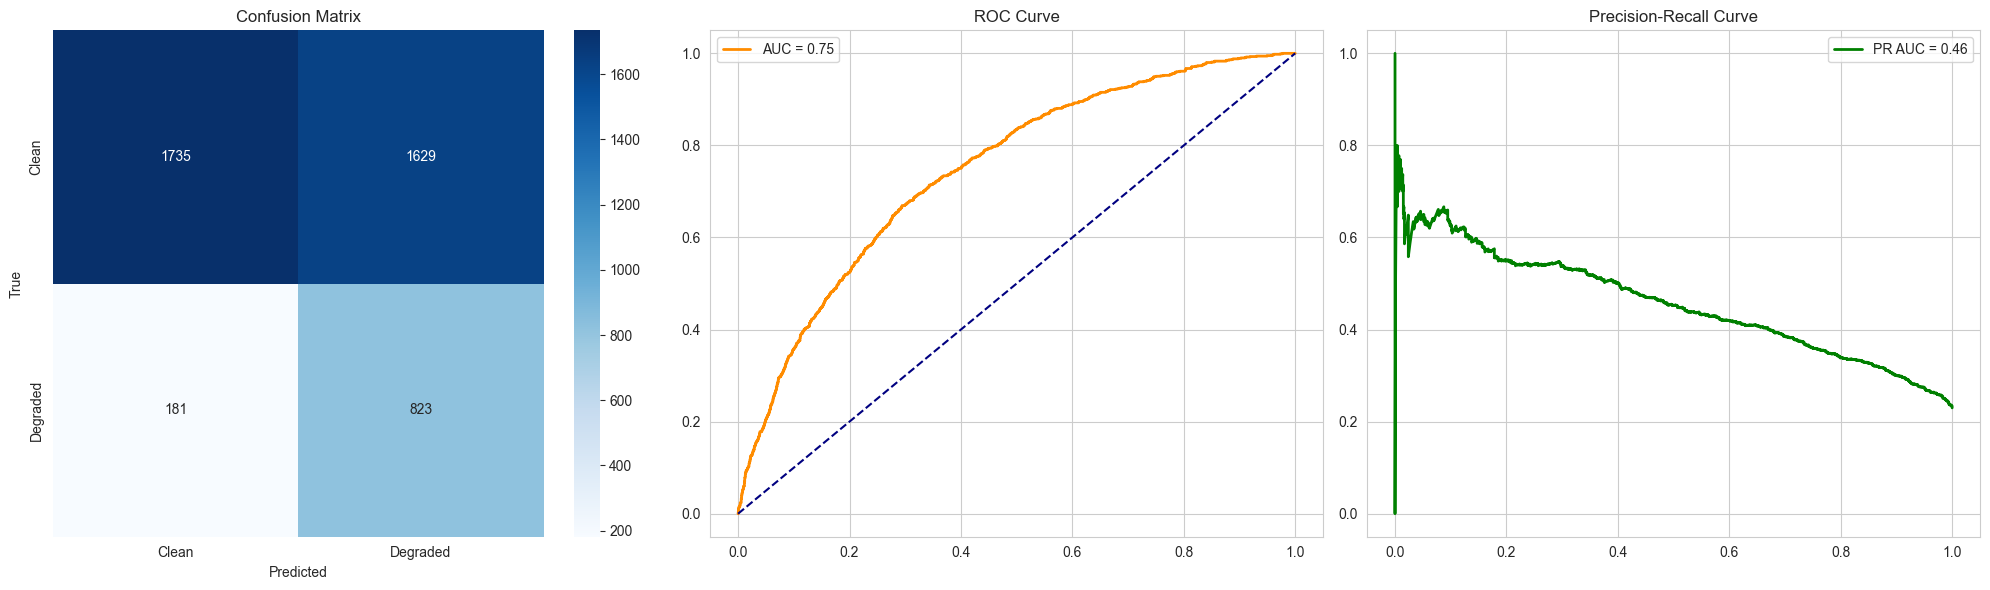

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve, 
    classification_report, roc_auc_score, average_precision_score, matthews_corrcoef
)
from torch.utils.data import DataLoader, WeightedRandomSampler

# Add current directory to path
if "." not in sys.path:
    sys.path.append(".")

# IMPORT THE V6 MODULE
import ptbxl_supervised_v6 as ptbxl

# ==========================================
# 1. HELPER: REPORT GENERATOR
# ==========================================
def generate_report(model, test_loader, device):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)
            
            all_targets.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print("\n" + "="*60)
    print("FINAL TEST EVALUATION (V6 MODEL)")
    print("="*60)
    
    print("Classification Report:")
    print(classification_report(all_targets, all_preds, target_names=["Clean", "Degraded"]))
    
    auc_score = roc_auc_score(all_targets, all_probs)
    auprc = average_precision_score(all_targets, all_probs)
    mcc = matthews_corrcoef(all_targets, all_preds)
    
    print(f"AUC:       {auc_score:.4f}")
    print(f"AUPRC:     {auprc:.4f}")
    print(f"MCC:       {mcc:.4f}")
    
    return all_targets, all_preds, all_probs

# ==========================================
# 2. MAIN EXECUTION
# ==========================================
def main():
    # PATHS
    DATA_ROOT = Path("/Users/reubenaddison/Downloads/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1/")
    DB_CSV = DATA_ROOT / "ptbxl_database.csv"
    OUT_DIR = Path("experiments/v6_production")

    if not DB_CSV.exists():
        print(f"❌ Error: Could not find database at {DB_CSV}")
        return

    # --- FIXED CONFIGURATION STEP ---
    # Instantiate default config first
    cfg = ptbxl.Config()
    
    # Overwrite with your settings
    cfg.data_root = DATA_ROOT
    cfg.db_csv = DB_CSV
    cfg.out_dir = OUT_DIR
    cfg.input_channels = 12
    cfg.fs_target = 100
    cfg.window_sec = 10
    cfg.batch_size = 64
    cfg.epochs = 40
    cfg.lr = 1e-4
    cfg.weight_decay = 1e-2
    cfg.dropout = 0.5
    cfg.patience = 8
    cfg.num_workers = 8  # Set to 0 if on Mac/Windows and getting DataLoader errors
    cfg.seed = 42

    print(f"🚀 Starting Pipeline V6...")
    
    try:
        ptbxl.seed_everything(cfg.seed)
        cfg.out_dir.mkdir(parents=True, exist_ok=True)
        
        # Load Data
        db = pd.read_csv(cfg.db_csv)
        y = ptbxl.build_degradation_labels(db)
        
        # Splits
        idx_all = np.arange(len(y))
        idx_train, idx_test = train_test_split(idx_all, test_size=0.2, stratify=y, random_state=cfg.seed)
        y_train_full = y[idx_train]
        idx_tr, idx_val = train_test_split(idx_train, test_size=0.2, stratify=y_train_full, random_state=cfg.seed)

        # Datasets
        ds_tr = ptbxl.PTBXLECGWindowDataset(db.iloc[idx_tr], y[idx_tr], cfg, mode="train")
        ds_val = ptbxl.PTBXLECGWindowDataset(db.iloc[idx_val], y[idx_val], cfg, mode="eval")
        
        # Sampler
        y_tr_indices = y[idx_tr]
        class_counts = np.bincount(y_tr_indices)
        sample_weights = 1. / class_counts[y_tr_indices]
        sampler = WeightedRandomSampler(torch.from_numpy(sample_weights).double(), len(sample_weights), replacement=True)

        # Loaders
        train_loader = DataLoader(ds_tr, batch_size=cfg.batch_size, sampler=sampler, num_workers=cfg.num_workers, drop_last=True)
        val_loader = DataLoader(ds_val, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

        # TRAIN
        model = ptbxl.train_model(cfg, train_loader, val_loader)
        
        # SAVE
        model_path = cfg.out_dir / "best_model_v6.pt"
        torch.save(model.state_dict(), model_path)
        print(f"\n✅ Training Complete. Model Saved to {model_path}")
        
        # VISUALIZE
        print("\n📊 Generating Plots & Report...")
        ds_test = ptbxl.PTBXLECGWindowDataset(db.iloc[idx_test], y[idx_test], cfg, mode="eval")
        test_loader = DataLoader(ds_test, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
        
        device = ptbxl.get_device()
        model.eval()
        
        all_targets, all_preds, all_probs = generate_report(model, test_loader, device)
        
        # PLOT
        sns.set_style("whitegrid")
        fig, ax = plt.subplots(1, 3, figsize=(20, 6))

        # CM
        cm = confusion_matrix(all_targets, all_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
        ax[0].set_title("Confusion Matrix")
        ax[0].set_xlabel("Predicted")
        ax[0].set_ylabel("True")
        ax[0].set_xticklabels(['Clean', 'Degraded'])
        ax[0].set_yticklabels(['Clean', 'Degraded'])

        # ROC
        fpr, tpr, _ = roc_curve(all_targets, all_probs)
        roc_val = auc(fpr, tpr)
        ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_val:.2f}')
        ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
        ax[1].set_title("ROC Curve")
        ax[1].legend()

        # PR
        prec, rec, _ = precision_recall_curve(all_targets, all_probs)
        pr_val = auc(rec, prec)
        ax[2].plot(rec, prec, color='green', lw=2, label=f'PR AUC = {pr_val:.2f}')
        ax[2].set_title("Precision-Recall Curve")
        ax[2].legend()

        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

In [22]:
summary = az.summary(trace_lr, var_names=["beta"])
summary["abs_mean"] = summary["mean"].abs()
summary = summary.sort_values("abs_mean", ascending=False)
summary.head(15)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,abs_mean
beta[8],0.422,0.121,0.193,0.643,0.002,0.001,3468.0,4160.0,1.0,0.422
beta[26],-0.396,0.143,-0.679,-0.136,0.002,0.002,6311.0,5056.0,1.0,0.396
beta[20],0.298,0.097,0.125,0.490,0.001,0.001,4304.0,5130.0,1.0,0.298
beta[9],0.295,0.054,0.193,0.396,0.001,0.001,5212.0,5445.0,1.0,0.295
beta[14],-0.284,0.120,-0.510,-0.062,0.002,0.001,3911.0,4679.0,1.0,0.284
beta[2],-0.283,0.146,-0.563,-0.012,0.002,0.002,7128.0,5087.0,1.0,0.283
beta[23],0.248,0.115,0.028,0.455,0.002,0.001,5440.0,4806.0,1.0,0.248
beta[44],-0.227,0.127,-0.467,0.006,0.002,0.001,3438.0,4399.0,1.0,0.227
beta[6],-0.213,0.134,-0.468,0.038,0.002,0.002,5044.0,4345.0,1.0,0.213
beta[41],0.210,0.116,0.004,0.441,0.002,0.001,4594.0,5306.0,1.0,0.210


In [26]:
summary = az.summary(trace_lr, var_names=["beta"])
summary["abs_mean"] = summary["mean"].abs()
summary["feature"] = lr_cols
summary = summary.set_index("feature")
summary = summary.sort_values("abs_mean", ascending=False)
summary.head(15)



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,abs_mean
feature,,,,,,,,,,
frac_hf_mean,0.422,0.121,0.193,0.643,0.002,0.001,3468.0,4160.0,1.0,0.422
p_0_40_mean,-0.396,0.143,-0.679,-0.136,0.002,0.002,6311.0,5056.0,1.0,0.396
pSQI_mean,0.298,0.097,0.125,0.490,0.001,0.001,4304.0,5130.0,1.0,0.298
frac_hf_min,0.295,0.054,0.193,0.396,0.001,0.001,5212.0,5445.0,1.0,0.295
hf_ratio_mean,-0.284,0.120,-0.510,-0.062,0.002,0.001,3911.0,4679.0,1.0,0.284
basSQI_mean,-0.283,0.146,-0.563,-0.012,0.002,0.002,7128.0,5087.0,1.0,0.283
p_0_1_mean,0.248,0.115,0.028,0.455,0.002,0.001,5440.0,4806.0,1.0,0.248
rr_jump_frac_mean,-0.227,0.127,-0.467,0.006,0.002,0.001,3438.0,4399.0,1.0,0.227
frac_base_min,-0.213,0.134,-0.468,0.038,0.002,0.002,5044.0,4345.0,1.0,0.213


In [27]:
summary[summary["r_hat"] > 1.01]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,abs_mean
feature,,,,,,,,,,


In [32]:
import numpy as np
import xarray as xr

# data
X = feat_df[lr_cols].to_numpy(dtype=np.float32)
Xz = (X - lr_mean) / lr_std
y = feat_df["y"].to_numpy(dtype=np.int32)

# posterior samples
beta = trace_lr.posterior["beta"]            # dims: chain, draw, D
alpha = trace_lr.posterior["alpha"]          # dims: chain, draw

# flatten chains+draws -> S samples
beta_s = beta.stack(sample=("chain","draw")).transpose("sample","beta_dim_0").values   # (S, D)
alpha_s = alpha.stack(sample=("chain","draw")).values                                  # (S,)

# predicted probabilities for each posterior sample
eta = alpha_s[:, None] + beta_s @ Xz.T          # (S, N)
p_post = 1 / (1 + np.exp(-eta))                 # (S, N)




In [33]:
p_mean = p_post.mean(axis=0)
p_lo = np.quantile(p_post, 0.03, axis=0)
p_hi = np.quantile(p_post, 0.97, axis=0)


In [35]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y, p_hat)
auc


0.6490177860976288

In [38]:
import pandas as pd
import numpy as np

def summarize_degradation_types_db(
    db: pd.DataFrame,
    noise_cols=None,
    top_patterns: int = 10
):
    """
    Summarize degradation types using PTB-XL metadata (db), not feat_df.

    Returns:
      type_summary_df: counts/percents for each noise column
      pattern_summary_df: top co-occurrence patterns (including 'clean')
      used_noise_cols: the columns actually used
    """
    # If user didn't pass columns, try common PTB-XL names
    if noise_cols is None:
        candidates = [
            "baseline_drift", "static_noise", "burst_noise", "electrodes_problems",
            "electrode_problems", "electrodes_problem", "electrodes",  # common variants
        ]
        noise_cols = [c for c in candidates if c in db.columns]

    # Hard fail with a helpful message if none found
    if not noise_cols:
        raise KeyError(
            "No noise columns found in db. "
            "Check db.columns and pass noise_cols explicitly."
        )

    def to_flag(s: pd.Series) -> pd.Series:
        """Nonzero / truthy => 1, else 0 (robust to strings, NaN)."""
        s2 = pd.to_numeric(s, errors="coerce").fillna(0.0)
        return (s2 != 0.0).astype(int)

    flags = pd.DataFrame({c: to_flag(db[c]) for c in noise_cols})
    N = len(flags)

    # Per-type summary
    type_summary = pd.DataFrame({
        "type": noise_cols,
        "count": [int(flags[c].sum()) for c in noise_cols],
    })
    type_summary["percent"] = 100 * type_summary["count"] / N
    type_summary = type_summary.sort_values("count", ascending=False).reset_index(drop=True)

    # Pattern summary (co-occurrence)
    pattern_key = flags.apply(lambda r: tuple(r.values.tolist()), axis=1)
    vc = pattern_key.value_counts().head(top_patterns)

    patt_rows = []
    for pat, cnt in vc.items():
        present = [noise_cols[i] for i, v in enumerate(pat) if v == 1]
        label = " + ".join(present) if present else "clean"
        patt_rows.append({
            "pattern": label,
            "count": int(cnt),
            "percent": 100 * int(cnt) / N
        })
    pattern_summary = pd.DataFrame(patt_rows)

    return type_summary, pattern_summary, noise_cols


In [42]:
for c in noise_cols:
    if c in db.columns:
        print("\n", c)
        print("dtype:", db[c].dtype)
        print("head values:", db[c].head(10).tolist())
        print("value counts (top):")
        print(db[c].astype(str).value_counts().head(10))



 baseline_drift
dtype: object
head values: [nan, nan, nan, ' , II,III,AVF', ' , III,AVR,AVF', ' , V1', nan, ' , II,AVF', nan, nan]
value counts (top):
baseline_drift
nan          20230
 , V6          222
 , V1           95
 , II-AVF       60
 , V3           59
 , V2           58
 , V5,V6        57
 , alles        55
 , I-AVF        47
 , V5           46
Name: count, dtype: int64

 static_noise
dtype: object
head values: [' , I-V1,  ', nan, nan, nan, nan, nan, nan, ' , I-AVF,  ', ' , I-AVR,  ', nan]
value counts (top):
static_noise
nan             18575
 , I-AVR,         953
 , I-AVF,         919
 , alles,         524
 , I-V1,          156
 , I-V2,          144
 , I-AVL,          91
 , mittel,         70
 , leicht,         42
 , I,II,           25
Name: count, dtype: int64

 burst_noise
dtype: object
head values: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
value counts (top):
burst_noise
nan      21224
alles      140
I-AVF       47
V1          46
V1,V2       28
I-AVR       24
V2